# The drop after Taiwan's forced short-covering deadline (融券強制回補)

**The rule.** TWSE margin rules (證券商辦理有價證券買賣融資融券業務操作辦法, Art. 76, amended 2026-01-09): new margin shorts
are banned for four days starting six business days before a book closure, and every existing margin short must be
bought back by that same day, **D**. `climb.ipynb` showed that heavily shorted stocks climb into D, and that the part
specific to short interest is the last ~3–6 days.

**The short thesis.** If that climb is price pressure from forced, price-insensitive buying, it should reverse once
the buying stops. Heavily shorted stocks should then fall after D, by more than the same stock does over an ordinary
stretch, by more than lightly shorted stocks on the same dates, and specifically after these dates.

**Design (mirrors `climb.ipynb`)**
* **Drop(x)** = dividend-adjusted return from the close of D to the close of D+x, for x = 1…15 (and out to 50 in 4d).
  A short position wants this to be negative.
* **Short pressure** is measured on D−17 (days-to-cover = short balance / 20-day average volume). These are the same Q5 stocks
  as in `climb.ipynb`, so the climb and the drop can be read as one round trip.
* **Null:** random windows of the same length from the same stock, away from its own deadlines (event level), or one
  random window per deadline cohort (t-stat level). p-values are one-sided in the direction of the thesis
  (real ≤ null).
* **Ex-dividend.** For ex-dividend deadlines the ex-date falls inside the window (typically D+4 trading days).
  Returns are adjusted with TWSE's ex-dividend reference prices (a matching row exists for 99% of those events), and
  section 5 repeats the key test with the ex-date's return removed entirely.

## 1. Data
**What this does.** Same panel as `climb.ipynb`: TWSE prices with dividend-adjusted returns, margin/short balances,
TAIEX, and the FinMind short-sale-ban calendar, as *days × stocks* matrices. It also builds an ex-date mask for the
robustness check.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.formula.api as smf

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
X_MAX = 15            # longest drop window (trading days after D)
SIG_LAG = 17          # short pressure measured on D-17 (same Q5 as climb.ipynb)
PRE = 10              # days before D shown on the path plots
IS_END = pd.Timestamp("2023-12-31")
N_BOOT = 2000; N_T_BOOT = 1000
COST_SHORT_STOCK_BPS, COST_FUT_BPS, MIN_VAL20 = 65, 20, 2e7
rng = np.random.default_rng(11)

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["exday"] = px["adj"].notna()
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)

R = wide(px, "ret")
EXDAY = wide(px, "exday").fillna(False).values.astype(bool)
mkt_ew = R.mean(axis=1)
SB, COVB = wide(mg, "short_bal"), wide(mg, "short_buy")
SSELL = wide(mg, "short_sell")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T, N = R.shape

def cumsum0(M):   # C[t+1] - C[a] = sum of M[a..t]
    return np.vstack([np.zeros((1, M.shape[1])), np.nancumsum(M, axis=0)])
LR = np.log1p(R.values)
LR_EW = LR - np.log1p(mkt_ew.values)[:, None]
C_RAW, C_EW = cumsum0(LR), cumsum0(LR_EW)
C_EW_NOEX = cumsum0(np.where(EXDAY, np.nan, LR_EW))      # robustness: ex-date returns removed
TRADED = ~np.isnan(R.values)
print(f"{T} trading days {cal[0].date()} -> {cal[-1].date()}, {N} stocks")

2122 trading days 2018-01-02 -> 2026-09-23, 1111 stocks


**What this does.** The event calendar, exactly as in `climb.ipynb`. D is the first day of each ban (= the last
covering day), keeping one event per stock per 10 trading days, with days-to-cover on D−17 and quintiles formed within
each year. Stocks with no margin shorts on D−17 form the control group. Also records the last day of each ban, when
margin shorting reopens.

In [2]:
REASON = [("股東常會", "AGM"), ("股東臨時會", "EGM"), ("除權息", "ex-rights+div"), ("除息", "ex-div"), ("除權", "ex-rights"),
          ("現金增資", "cash raise")]
def reason_en(s):
    for k, v in REASON:
        if k in s:
            return v
    return "other"

ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["why"] = ev.reason.map(reason_en)
ev["D"] = cal.searchsorted(ev.date.values)
ev["E"] = cal.searchsorted(ev.end_date.values, side="right") - 1           # last day of the ban
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.D < T - 2)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
ev["Ddate"] = cal[ev.D.values]
ev["year"] = ev.Ddate.dt.year
ev["oos"] = ev.Ddate > IS_END

s_ = ev.D.values - SIG_LAG
J = ev.j.values
ev["sb_sig"] = SB.values[s_, J]
ev["dtc"] = SB.values[s_, J] / ADV.values[s_, J]
ev["size"] = VAL20.values[s_, J]
ev = ev[np.isfinite(ev.sb_sig) & np.isfinite(ev["size"])].reset_index(drop=True)
quint = lambda s: np.ceil(s.rank(method="first", pct=True) * 5)
ev["grp"] = "no shorts"
has = (ev.sb_sig > 0) & np.isfinite(ev.dtc)
ev.loc[has, "grp"] = "Q" + ev[has].groupby("year").dtc.transform(quint).astype(int).astype(str)
GROUPS = ["no shorts", "Q1", "Q2", "Q3", "Q4", "Q5"]
D, J = ev.D.values, ev.j.values
ban_len = (ev.E - ev.D + 1)
print(f"{len(ev):,} events on {ev.Ddate.nunique()} deadline dates, {ev.stock_id.nunique()} stocks")
print(f"ban length (trading days): median {ban_len.median():.0f}, share = 4 days: {(ban_len == 4).mean():.1%}")
print(ev.groupby("grp").agg(n=("dtc", "size"), dtc_median=("dtc", "median")).round(3).to_string())

16,094 events on 1350 deadline dates, 1098 stocks
ban length (trading days): median 4, share = 4 days: 93.1%
              n  dtc_median
grp                        
Q1         2280       0.004
Q2         2284       0.016
Q3         2285       0.040
Q4         2284       0.086
Q5         2287       0.254
no shorts  4674       0.000


## 2. The mechanism: what happens to short interest after D?
**What this does.** Short balance relative to its D−17 level, and new short-sale volume (as a multiple of normal
daily volume), from D−10 to D+15, by group. When the ban ends the shorts can come back. If they do so quickly, that is
selling pressure on top of the removed buying.

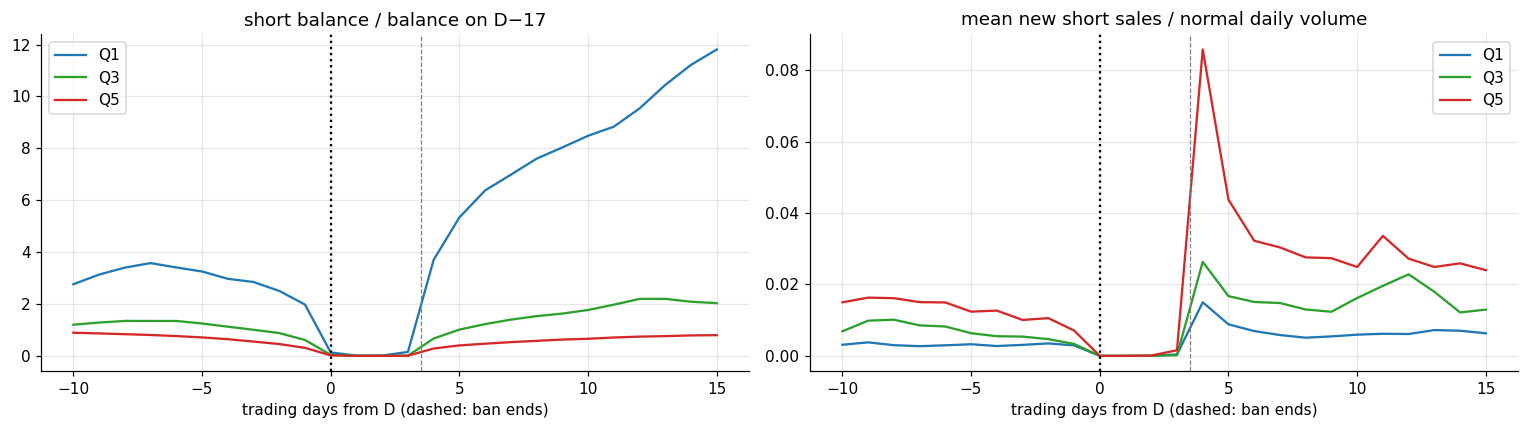

Q5 short balance on D+0: 2% of the D-17 level
Q5 short balance on D+1: 0% of the D-17 level
Q5 short balance on D+3: 1% of the D-17 level
Q5 short balance on D+4: 28% of the D-17 level
Q5 short balance on D+5: 40% of the D-17 level
Q5 short balance on D+10: 66% of the D-17 level
Q5 short balance on D+15: 80% of the D-17 level


In [3]:
offs = np.arange(-PRE, X_MAX + 1)
def ev_mat(M, D_, J_):
    ii = D_[:, None] + offs[None, :]
    ok = (ii >= 0) & (ii < T)
    out = np.full(ii.shape, np.nan)
    out[ok] = M[ii[ok], np.broadcast_to(J_[:, None], ii.shape)[ok]]
    return out

base = ev.sb_sig.where(ev.sb_sig > 0).values[:, None]
SBn = ev_mat(SB.values, D, J) / base
SSn = ev_mat(SSELL.values, D, J) / ADV.values[D - SIG_LAG, J][:, None]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for g_, c in [("Q1", "C0"), ("Q3", "C2"), ("Q5", "C3")]:
    m = (ev.grp == g_).values
    ax[0].plot(offs, np.nanmean(SBn[m], 0), color=c, label=g_)
    ax[1].plot(offs, np.nanmean(SSn[m], 0), color=c, label=g_)
ax[0].set_title("short balance / balance on D−17"); ax[1].set_title("mean new short sales / normal daily volume")
for a in ax:
    a.axvline(0, color="k", ls=":"); a.axvline(3.5, color="C7", ls="--", lw=.8); a.legend(); a.set_xlabel("trading days from D (dashed: ban ends)")
plt.tight_layout(); plt.show()
q5 = (ev.grp == "Q5").values
left = np.nanmean(SBn[q5], 0)
for d_ in [0, 1, 3, 4, 5, 10, 15]:
    print(f"Q5 short balance on D{d_:+d}: {left[offs == d_][0]:.0%} of the D-17 level")

## 3. The drop
**What this does.** Mean drop(x) for x = 1…15 by group, raw and relative to the equal-weighted market, and the average
price path from D−10 to D+15, set to 0 at the close of D, with 95% bands (standard errors clustered by deadline date).

x                      1     3      5      10     15
kind      group                                     
raw       Q1          4.4  32.2   22.7  -17.1   -9.9
          Q2        -16.9  11.9   16.7  -39.8  -40.8
          Q3        -19.9  11.2    0.4  -58.4  -66.8
          Q4        -35.2   2.0    0.5  -58.6  -72.4
          Q5        -59.5 -52.3  -73.2 -162.0 -219.3
          no shorts   2.3  41.6   63.2   47.2   35.8
vs market Q1          9.3   7.1  -14.0  -38.2  -53.2
          Q2        -10.3  -6.2  -13.1  -39.0  -60.6
          Q3        -14.4  -9.9  -27.9  -63.2  -88.8
          Q4        -35.5 -30.6  -42.7  -71.2 -107.2
          Q5        -55.5 -69.8 -112.9 -181.5 -250.5
          no shorts   6.2  16.3   21.0    8.3   -8.9

t-stats (clustered by deadline date)
x                      1     3     5     10    15
kind      group                                  
raw       Q1         0.49  1.61  1.17 -0.39 -0.25
          Q2        -1.71  0.62  0.85 -0.77 -0.89
          Q3        

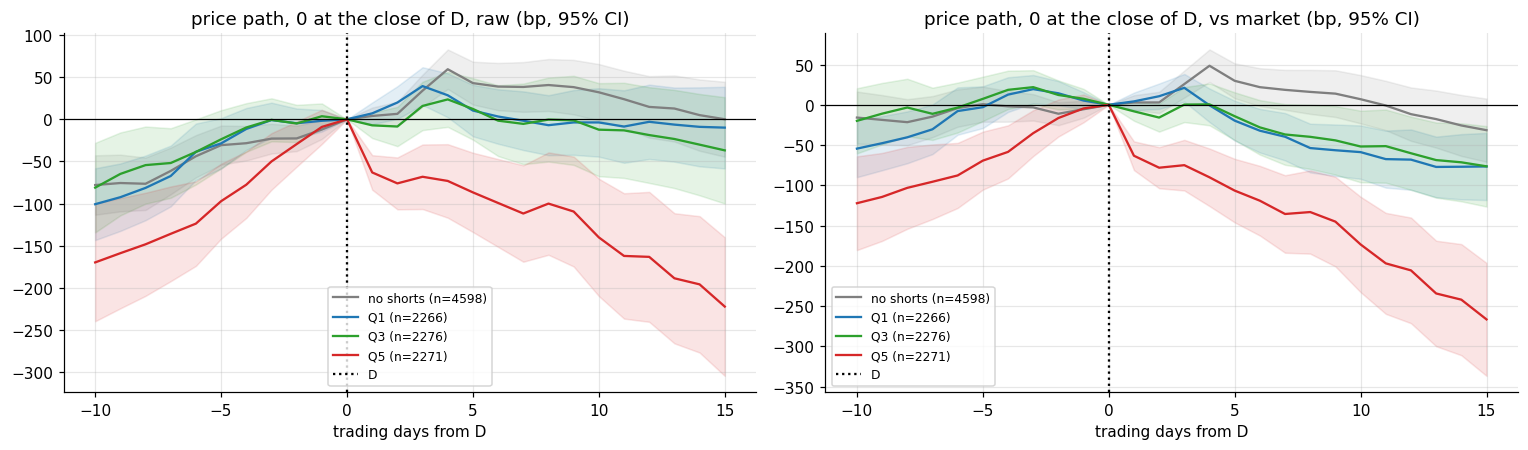

In [4]:
XS = np.arange(1, X_MAX + 1)
def drop(D_, J_, C, xs=XS):
    # (n, len(xs)): log return from the close of D to the close of D+x
    return C[np.minimum((D_ + 1)[:, None] + xs[None, :], T), J_[:, None]] - C[D_ + 1, J_][:, None]

ok_ev = TRADED[D, J] & TRADED[np.minimum(D + X_MAX, T - 1), J] & (D + X_MAX + 1 < T)
CL = {"raw": drop(D, J, C_RAW), "vs market": drop(D, J, C_EW)}
for k in CL: CL[k][~ok_ev] = np.nan

def clustered_mean(x, dates):
    d = pd.DataFrame({"x": x, "d": dates}).dropna()
    g = d.groupby("d").x.agg(["sum", "count"])
    m = g["sum"].sum() / g["count"].sum()
    resid = (g["sum"] - m * g["count"]).values
    return m, np.sqrt((resid ** 2).sum()) / g["count"].sum()

rows = []
for kind, M in CL.items():
    for g_ in GROUPS:
        m = (ev.grp == g_).values
        for x in [1, 3, 5, 10, 15]:
            mu, se = clustered_mean(M[m, x - 1], ev.Ddate.values[m])
            rows.append(dict(kind=kind, group=g_, x=x, mean_bp=mu * 1e4, t=mu / se))
tab = pd.DataFrame(rows)
print(tab.pivot_table(index=["kind", "group"], columns="x", values="mean_bp").round(1).to_string())
print("\nt-stats (clustered by deadline date)")
print(tab.pivot_table(index=["kind", "group"], columns="x", values="t").round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a, (k, LRk) in zip(ax, [("raw", LR), ("vs market", LR_EW)]):
    P = np.cumsum(np.nan_to_num(ev_mat(LRk, D, J)), 1); P = (P - P[:, [PRE]]) * 1e4     # 0 at the close of D
    for g_, c in [("no shorts", "C7"), ("Q1", "C0"), ("Q3", "C2"), ("Q5", "C3")]:
        m = (ev.grp == g_).values & ok_ev
        df = pd.DataFrame(P[m], columns=offs).assign(d=ev.Ddate.values[m]).groupby("d").mean()
        mu, se = df.mean(), df.std() / np.sqrt(len(df))
        a.plot(offs, mu, color=c, label=f"{g_} (n={m.sum()})"); a.fill_between(offs, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.12)
    a.axvline(0, color="k", ls=":", label="D"); a.axhline(0, color="k", lw=.8)
    a.set_title(f"price path, 0 at the close of D, {k} (bp, 95% CI)"); a.set_xlabel("trading days from D"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
- **Mechanism.** The ban keeps Q5 short balances at ~0–2% of their D−17 level through D+3. When margin shorting
  reopens they come straight back: 28% on D+4, 40% on D+5, 66% on D+10, 80% on D+15. So after D the forced buying
  stops, and from D+4 new short selling starts.
- **Only the heavily shorted stocks fall.** Against the market, Q5 drops **−56bp on the first day (t = −9.3)**, −113bp
  by D+5 and −251bp by D+15 (t = −8.8). The decline is monotone across quintiles: at D+15, Q1 −53, Q2 −61, Q3 −89,
  Q4 −107, Q5 −251bp. The no-shorts control is flat to slightly up (+21bp at D+5, −9bp at D+15).
- **Raw**, Q5 falls −219bp over 15 days while no-shorts stocks *rise* (+36bp), so this is not a market move.

## 4. Is the drop bigger than an ordinary stretch for the same stock? (bootstrap)
**What this does.** Same as `climb.ipynb` §4, mirrored. For every event, a random window of the same length is drawn
from **the same stock**, starting on a day whose window cannot overlap [D−15, D+25] of any of that stock's own
deadlines. The statistic is the mean drop(x) across a group's events, and 2,000 draws give the null. p-values are
one-sided: real ≤ null. The **same-season** version draws only windows starting in the same calendar month in other years. It is thin
here: deadlines fall in the same months every year, so most same-month windows sit near another deadline and are
excluded (median ~3 candidate windows per event). Read it as a rough check.

In [5]:
# valid random-window START days per stock: traded at start and end, window [s, s+15] clear of own [D-15, D+25]
VALID = TRADED & np.roll(TRADED, -X_MAX, axis=0)
VALID[T - X_MAX - 2:] = False
for d_, j_ in zip(D, J):
    VALID[max(d_ - 15 - X_MAX, 0): min(d_ + 26, T), j_] = False

def make_pools(key_fn):
    keys = {}
    ee, jj = np.nonzero(VALID)
    for e_, j_ in zip(ee, jj):
        keys.setdefault(key_fn(e_, j_), []).append(e_)
    return keys

month = cal.month.values; yr = cal.year.values
pools_stock = make_pools(lambda e_, j_: j_)
pools_season = make_pools(lambda e_, j_: (j_, month[e_], yr[e_]))

def event_pool(pools, keys_per_event):
    flat, start, size = [], np.zeros(len(ev), int), np.zeros(len(ev), int)
    cache, offset = {}, 0
    for i, ks in enumerate(keys_per_event):
        kk = tuple(ks)
        if kk not in cache:
            arr = np.concatenate([np.asarray(pools[k]) for k in ks if k in pools] or [np.array([], int)])
            cache[kk] = (offset, len(arr)); flat.append(arr); offset += len(arr)
        start[i], size[i] = cache[kk]
    return np.concatenate(flat).astype(np.int32), start, size

P_STOCK = event_pool(pools_stock, [[j_] for j_ in J])
P_SEASON = event_pool(pools_season, [[(j_, m_, y_) for y_ in range(cal[0].year, cal[-1].year + 1) if y_ != yv]
                                     for j_, m_, yv in zip(J, month[D], yr[D])])
print(f"median random windows available per event: same stock {np.median(P_STOCK[2]):.0f}, same stock & month {np.median(P_SEASON[2]):.0f}")

def bootstrap(pool, C, CLk, n_boot=N_BOOT, chunk=40):
    flat, start, size = pool
    ok = size > 0
    gmask = {g_: ((ev.grp == g_).values & ok_ev & ok) for g_ in GROUPS}
    out = {g_: np.empty((n_boot, X_MAX)) for g_ in GROUPS + ["Q5-Q1"]}
    for b0 in range(0, n_boot, chunk):
        nb = min(chunk, n_boot - b0)
        u = rng.random((nb, len(ev)))
        S = flat[np.minimum(start + (u * size).astype(int), len(flat) - 1)]            # (nb, n) random start days
        cl = C[(S + 1)[..., None] + XS, J[None, :, None]] - C[S + 1, J][..., None]      # (nb, n, 15)
        cl[:, ~ok] = np.nan
        for g_, m in gmask.items():
            out[g_][b0:b0 + nb] = np.nanmean(cl[:, m], axis=1)
        out["Q5-Q1"][b0:b0 + nb] = out["Q5"][b0:b0 + nb] - out["Q1"][b0:b0 + nb]
    real = {g_: np.nanmean(CLk[m], 0) for g_, m in gmask.items()}
    real["Q5-Q1"] = real["Q5"] - real["Q1"]
    return real, out

res = {}
for kind, CM in [("raw", C_RAW), ("vs market", C_EW)]:
    for pname, pool in [("same stock", P_STOCK), ("same stock, same month", P_SEASON)]:
        res[(kind, pname)] = bootstrap(pool, CM, CL[kind])

def summary(real, null, g_):
    r, n = real[g_] * 1e4, null[g_] * 1e4
    return pd.DataFrame({"real_bp": r, "null_mean_bp": n.mean(0), "null_2.5%": np.percentile(n, 2.5, axis=0),
                         "excess_bp": r - n.mean(0), "z": (r - n.mean(0)) / n.std(0),
                         "p_one_sided": ((n <= r).sum(0) + 1) / (len(n) + 1)}, index=pd.Index(XS, name="x"))

for g_ in ["Q5", "Q1", "no shorts", "Q5-Q1"]:
    print(f"\n==== {g_}: drop(x) vs same-stock random windows, relative to market")
    print(summary(*res[("vs market", "same stock")], g_).round(3).to_string())

median random windows available per event: same stock 1099, same stock & month 3



==== Q5: drop(x) vs same-stock random windows, relative to market
    real_bp  null_mean_bp  null_2.5%  excess_bp       z  p_one_sided
x                                                                   
1   -55.500        -0.482     -9.654    -55.018 -11.395          0.0
2   -66.595        -1.157    -14.483    -65.439  -9.506          0.0
3   -69.819        -1.842    -18.920    -67.976  -7.864          0.0
4   -94.142        -2.389    -21.165    -91.753  -9.186          0.0
5  -112.937        -2.995    -24.785   -109.942  -9.840          0.0
6  -129.567        -3.557    -26.620   -126.010 -10.511          0.0
7  -143.693        -3.954    -29.392   -139.739 -10.770          0.0
8  -140.867        -4.512    -31.212   -136.355  -9.864          0.0
9  -150.658        -5.114    -33.480   -145.544  -9.992          0.0
10 -181.498        -5.826    -35.958   -175.672 -11.496          0.0
11 -202.919        -6.611    -38.046   -196.307 -12.161          0.0
12 -203.077        -7.436    -40.338

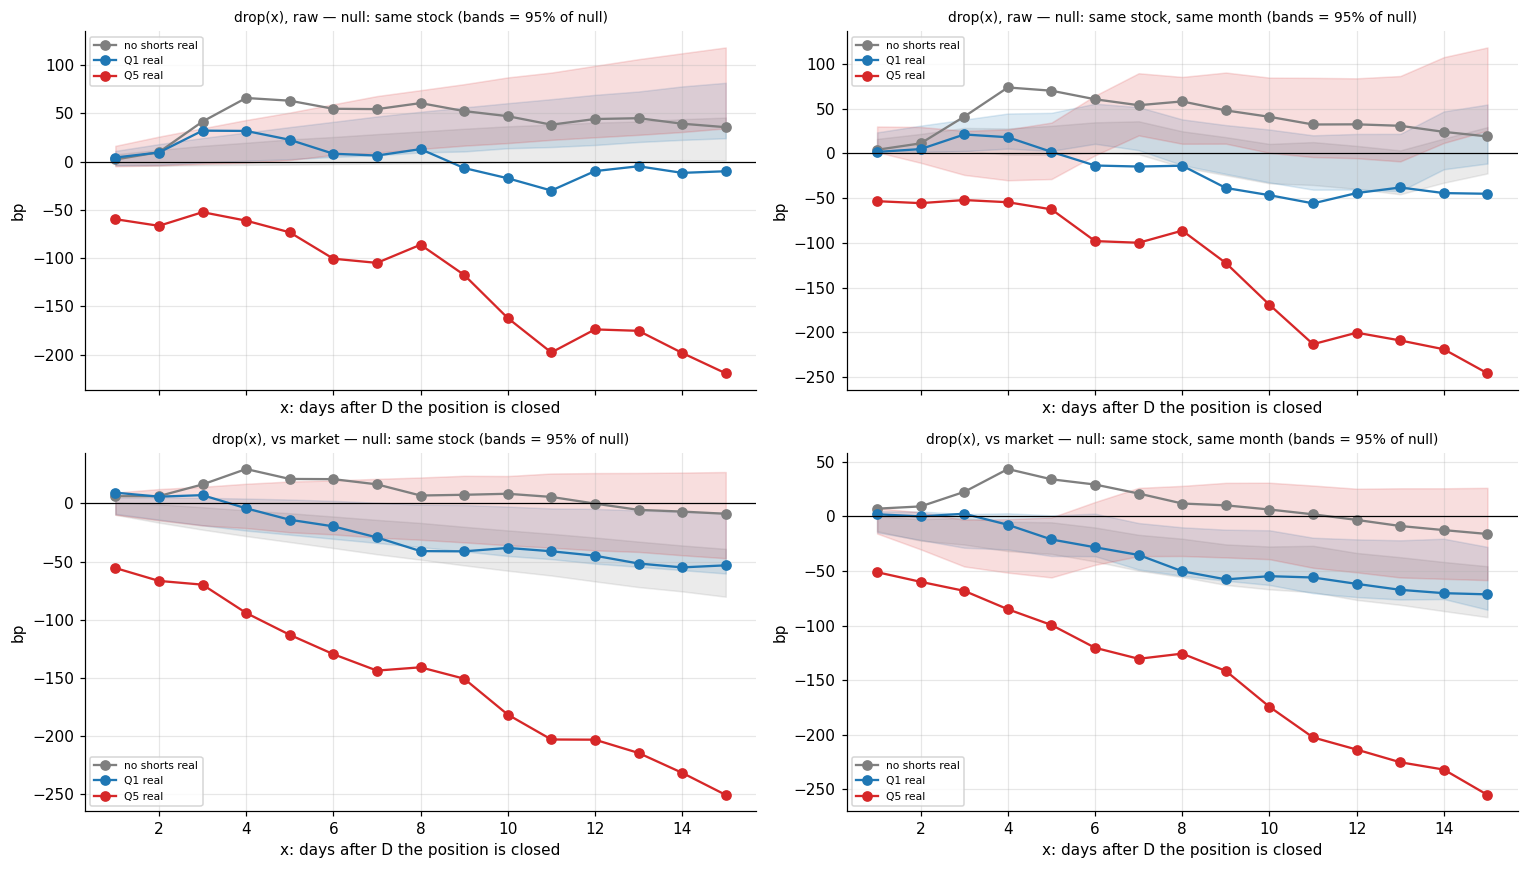

                                            x=3 excess  x=5 excess  x=10 excess  x=15 excess  x=3 p  x=5 p  x=10 p  x=15 p
returns   null                   group                                                                                    
raw       same stock             no shorts      35.641      53.593       29.580       12.541  1.000  1.000   1.000   0.873
                                 Q1             20.424       3.606      -54.022      -62.918  0.999  0.660   0.000   0.000
                                 Q2             -1.396      -5.081      -82.683     -103.177  0.428  0.317   0.000   0.000
                                 Q3             -3.780     -24.391     -107.527     -138.412  0.331  0.011   0.000   0.000
                                 Q4            -15.608     -28.665     -117.110     -156.635  0.046  0.008   0.000   0.000
                                 Q5            -68.053     -99.361     -214.678     -294.649  0.000  0.000   0.000   0.000
                

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax_row, kind in zip(axes, ["raw", "vs market"]):
    for a, pname in zip(ax_row, ["same stock", "same stock, same month"]):
        real, null = res[(kind, pname)]
        for g_, c in [("no shorts", "C7"), ("Q1", "C0"), ("Q5", "C3")]:
            n = null[g_] * 1e4
            a.plot(XS, real[g_] * 1e4, "o-", color=c, label=f"{g_} real")
            a.fill_between(XS, np.percentile(n, 2.5, 0), np.percentile(n, 97.5, 0), color=c, alpha=.15)
        a.axhline(0, color="k", lw=.8); a.set_title(f"drop(x), {kind} — null: {pname} (bands = 95% of null)", fontsize=9)
        a.set_xlabel("x: days after D the position is closed"); a.set_ylabel("bp"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

rows = []
for (kind, pname), (real, null) in res.items():
    for g_ in GROUPS + ["Q5-Q1"]:
        s = summary(real, null, g_)
        rows.append(dict(returns=kind, null=pname, group=g_, **{f"x={x} excess": s.loc[x, "excess_bp"] for x in [3, 5, 10, 15]},
                         **{f"x={x} p": s.loc[x, "p_one_sided"] for x in [3, 5, 10, 15]}))
print(pd.DataFrame(rows).set_index(["returns", "null", "group"]).round(3).to_string())

**Interpretation.**
- The same-stock null for Q5 barely moves (−0.5bp at 1 day, −10bp at 15 days), while the real Q5 drop is −55bp to
  −251bp. **Every x from 1 to 15 lies beyond all 2,000 draws (z = −8 to −13).**
- The cleaner cross-sectional test, **Q5 − Q1 vs its null**, is just as extreme: −65bp at 1 day, −99bp at 5,
  −143bp at 10 and −197bp at 15, all beyond every draw.
- The null's volatility drag (see `climb.ipynb`) shows up again. No-shorts stocks look "significantly up" against
  their own random windows, which is why the group comparisons are the ones to read. Here, unlike the climb, the
  result is overwhelming whichever way it is read.
- The thin same-month null gives the same answer (Q5 −71bp excess at 5 days, −240bp at 15, all p < 0.001).

### 4b. Bootstrap on the bucket's t-stat
**What this does.** As in `climb.ipynb` §4b. For each deadline date, average the drop(x) of the bucket's stocks (one
portfolio return per date), and take the t-stat across dates. For the null, every date's cohort gets one shared random
window (preserving co-movement) that is clear of the cohort's own [D−15, D+25] and of each stock's own deadlines.
Repeat 1,000 times and see where the real t-stat falls. The short thesis needs the real t-stat in the **left** tail.

In [7]:
coh, coh_idx = np.unique(ev.Ddate.values, return_inverse=True)
n_coh = len(coh)
D_coh = cal.searchsorted(coh)
grp = ev.grp.values

def coh_mean(vals, mask):
    w = mask & np.isfinite(vals)
    s_ = np.bincount(coh_idx[w], weights=vals[w], minlength=n_coh)
    c_ = np.bincount(coh_idx[w], minlength=n_coh)
    return np.where(c_ > 0, s_ / np.maximum(c_, 1), np.nan)

def tstat(r):
    r = r[np.isfinite(r)]
    return r.mean() / r.std(ddof=1) * np.sqrt(len(r)), r.mean(), len(r)

def bucket_ret(vals, valid, g_):
    if g_ == "Q5-Q1":
        return coh_mean(vals, valid & (grp == "Q5")) - coh_mean(vals, valid & (grp == "Q1"))
    return coh_mean(vals, valid & (grp == g_))

def random_starts(xmax, lo_pad=15, hi_pad=25):
    s = rng.integers(1, T - xmax - 2, n_coh)
    bad = (s >= D_coh - lo_pad - xmax) & (s <= D_coh + hi_pad)
    while bad.any():
        s[bad] = rng.integers(1, T - xmax - 2, bad.sum())
        bad = (s >= D_coh - lo_pad - xmax) & (s <= D_coh + hi_pad)
    return s

BUCKETS = ["Q5", "Q1", "no shorts", "Q5-Q1"]
XT = [3, 5, 10, 15]
tres = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {}
    for x in XT:
        for g_ in BUCKETS:
            real[(g_, x)] = tstat(bucket_ret(CL[kind][:, x - 1], ok_ev, g_))
    null = {k: np.empty(N_T_BOOT) for k in real}
    for b in range(N_T_BOOT):
        S = random_starts(X_MAX)[coh_idx]
        valid = VALID[S, J]
        for x in XT:
            v = CM[S + 1 + x, J] - CM[S + 1, J]
            for g_ in BUCKETS:
                null[(g_, x)][b] = tstat(bucket_ret(v, valid, g_))[0]
    tres[kind] = (real, null)

for kind, (real, null) in tres.items():
    rows = []
    for (g_, x), (t_real, mu, n_) in real.items():
        nl = null[(g_, x)]
        rows.append(dict(bucket=g_, x=x, dates=n_, real_mean_bp=mu * 1e4, real_t=t_real, null_t_mean=nl.mean(),
                         null_t_2_5=np.percentile(nl, 2.5), null_t_97_5=np.percentile(nl, 97.5),
                         pct_rank=(nl < t_real).mean() * 100, p_one_sided=((nl <= t_real).sum() + 1) / (len(nl) + 1)))
    print(f"\n==== {kind}: real t-stat vs 1,000 random-window t-stats (short thesis: real in the left tail)")
    print(pd.DataFrame(rows).set_index(["bucket", "x"]).round(3).to_string())


==== vs market: real t-stat vs 1,000 random-window t-stats (short thesis: real in the left tail)
              dates  real_mean_bp  real_t  null_t_mean  null_t_2_5  null_t_97_5  pct_rank  p_one_sided
bucket    x                                                                                           
Q5        3     681       -74.954  -4.679       -0.216      -2.297        1.805       0.0        0.001
Q1        3     670        21.064   2.402       -0.698      -2.663        1.238     100.0        1.000
no shorts 3     901        25.705   3.005       -1.178      -3.455        0.749     100.0        1.000
Q5-Q1     3     423      -117.235  -5.773        0.267      -1.676        2.226       0.0        0.001
Q5        5     681      -106.510  -5.293       -0.267      -2.232        1.653       0.0        0.001
Q1        5     670       -19.672  -1.561       -0.884      -2.894        1.106      25.9        0.260
no shorts 5     901        29.758   2.698       -1.510      -3.693        0.49

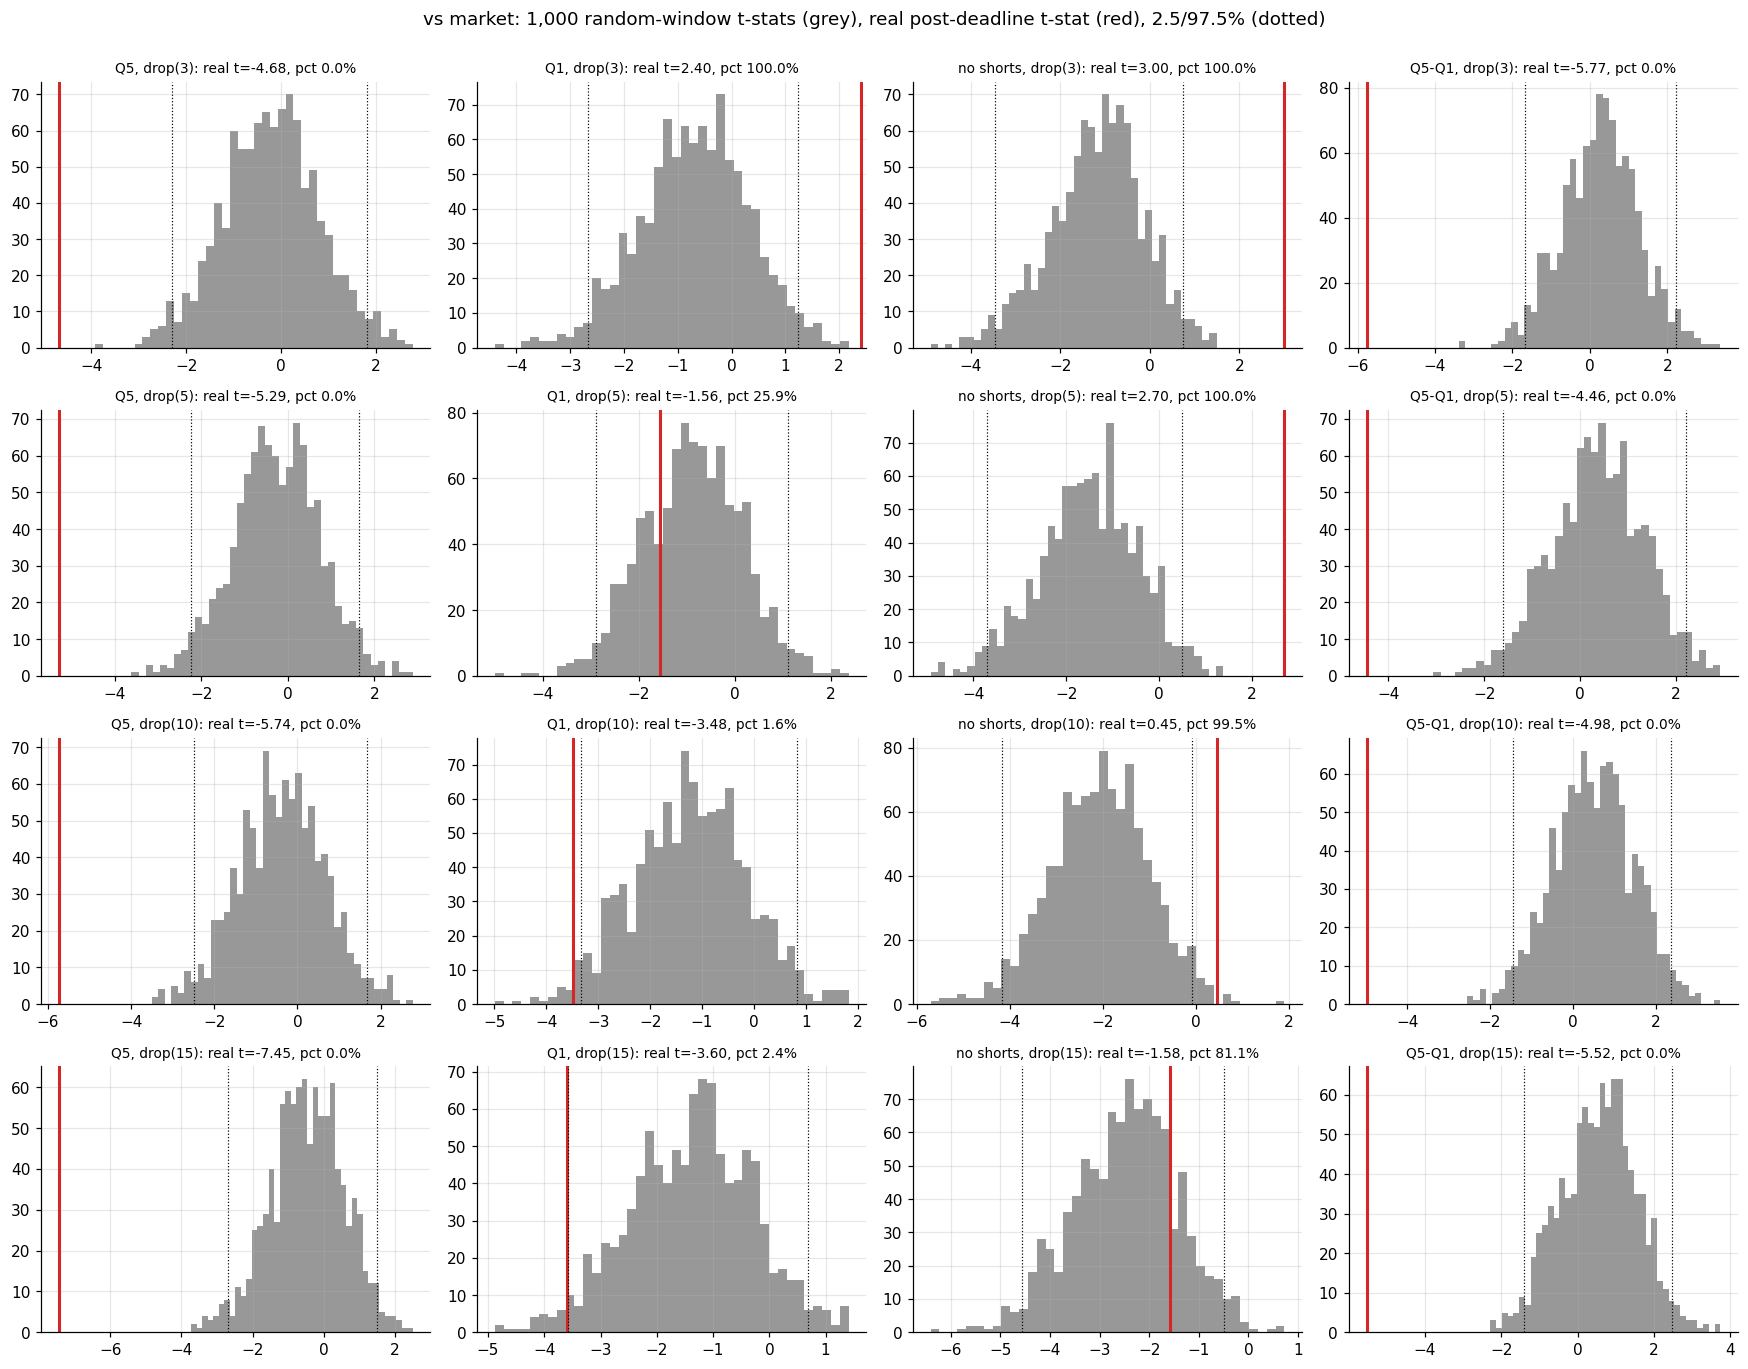

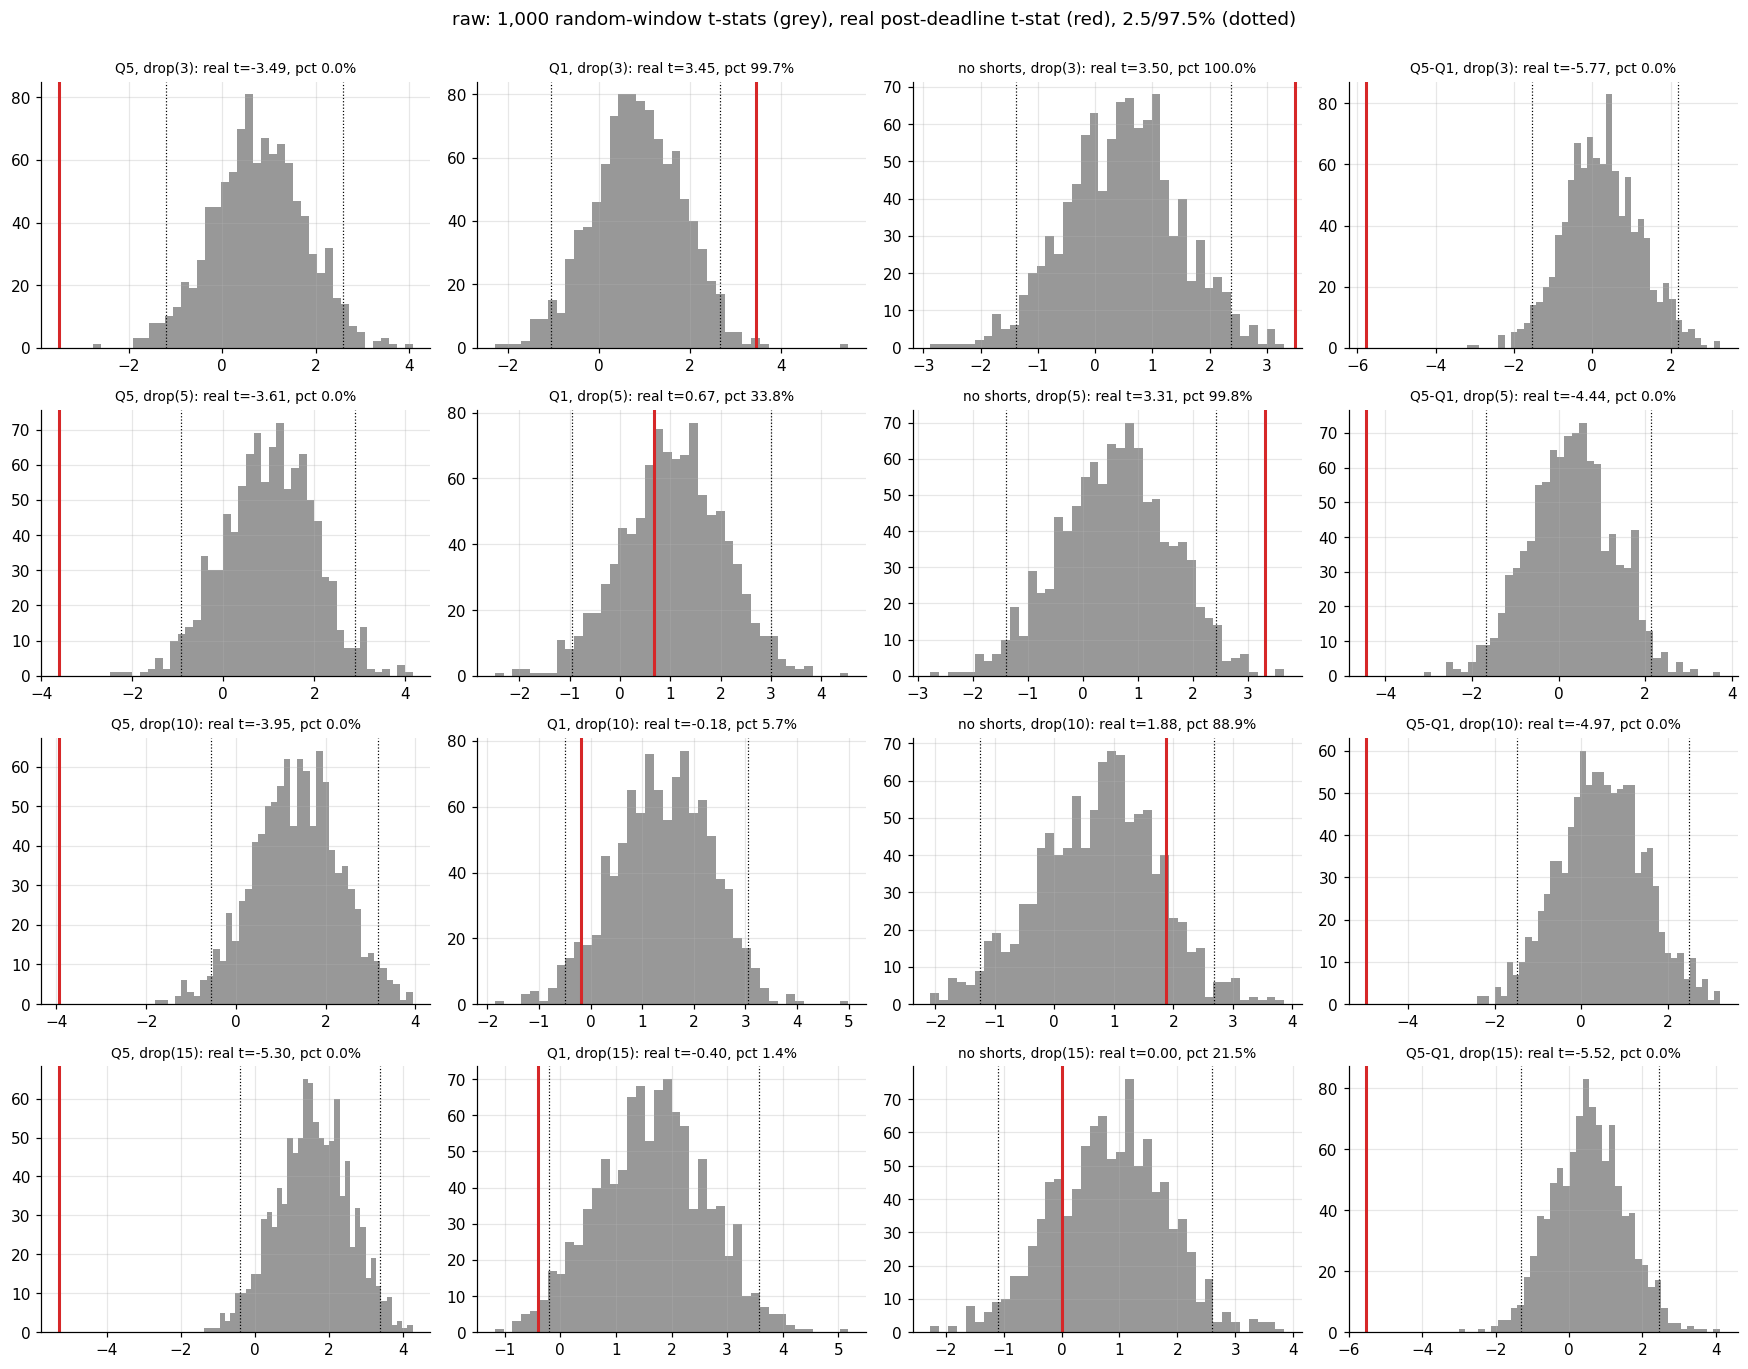

In [8]:
for kind, (real, null) in tres.items():
    fig, axes = plt.subplots(len(XT), len(BUCKETS), figsize=(16, 3.1 * len(XT)))
    for r_, x in enumerate(XT):
        for c_, g_ in enumerate(BUCKETS):
            a = axes[r_, c_]; nl = null[(g_, x)]; t_real = real[(g_, x)][0]
            a.hist(nl, bins=40, color="C7", alpha=.8)
            a.axvline(t_real, color="C3", lw=2)
            for q in [2.5, 97.5]: a.axvline(np.percentile(nl, q), color="k", ls=":", lw=.8)
            a.set_title(f"{g_}, drop({x}): real t={t_real:.2f}, pct {(nl < t_real).mean():.1%}", fontsize=9)
    fig.suptitle(f"{kind}: 1,000 random-window t-stats (grey), real post-deadline t-stat (red), 2.5/97.5% (dotted)", y=1.0)
    plt.tight_layout(); plt.show()

**Interpretation.**
- **Q5's real t-stat sits far in the left tail at every horizon.** Against the market: −4.7 at 3 days, −5.3 at 5,
  −5.7 at 10, −7.4 at 15. The null's 2.5th percentile is about −2.3 to −2.7, and none of the 1,000 random windows is as
  low (p ≤ 0.001).
- **Q5 − Q1 is just as extreme** (t = −5.8, −4.5, −5.0, −5.5), so this is specific to heavy short interest, not a
  post-book-closure effect common to all stocks.
- Unlike the climb, the lightly shorted and no-shorts buckets do *not* fall with Q5. Q1 is slightly *up* at 3 days
  (t = +2.4) and no-shorts is up at 3–5 days. At 10–15 days Q1 drifts down (t ≈ −3.5, 2nd percentile), so part of the
  longer tail is shared, but Q5 − Q1 stays at t ≈ −5.
- Raw returns give the same picture: Q5 t = −3.5 to −5.3 against a raw null centred above zero.

### 4c. Q5: t-stat by days after the deadline
**What this does.** Section 4b for every x = 1…15, Q5 only. The x-axis is days after D (the position runs from the
close of D to the close of D+x). The red line is the real t-stat and the grey band is the middle 95% of the 1,000 null t-stats.

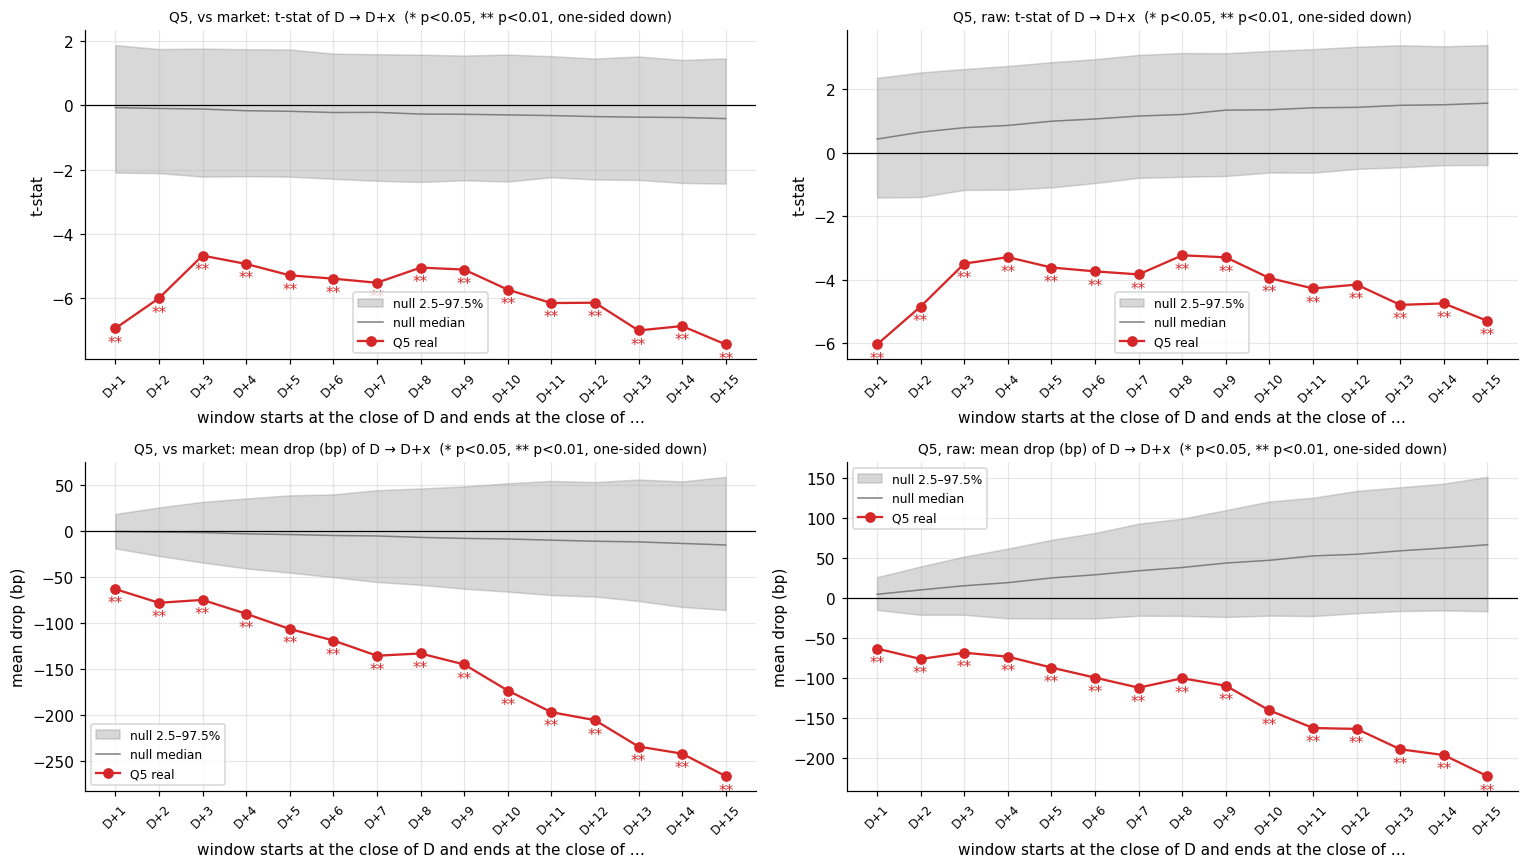


==== Q5, vs market
    real_mean_bp  real_t  null_t_median  null_t_2.5%  pct_rank  p_one_sided
x                                                                          
1        -63.238  -6.947         -0.067       -2.092       0.0        0.001
2        -78.101  -6.007         -0.092       -2.108       0.0        0.001
3        -74.954  -4.679         -0.111       -2.218       0.0        0.001
4        -90.020  -4.938         -0.163       -2.207       0.0        0.001
5       -106.510  -5.293         -0.182       -2.218       0.0        0.001
6       -119.046  -5.397         -0.219       -2.285       0.0        0.001
7       -135.546  -5.525         -0.214       -2.347       0.0        0.001
8       -133.137  -5.053         -0.268       -2.384       0.0        0.001
9       -145.035  -5.114         -0.274       -2.331       0.0        0.001
10      -173.348  -5.739         -0.294       -2.369       0.0        0.001
11      -196.832  -6.158         -0.314       -2.236       0.0      

In [9]:
q5m = grp == "Q5"
def q5_t_all(CM, S, valid, xs, mask=q5m):
    cl = CM[np.minimum((S + 1)[:, None] + xs[None, :], T), J[:, None]] - CM[S + 1, J][:, None]
    t_, mu = np.empty(len(xs)), np.empty(len(xs))
    for k in range(len(xs)):
        t_[k], mu[k], _ = tstat(coh_mean(cl[:, k], valid & mask))
    return t_, mu

q5res = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    t_real, mu_real = q5_t_all(CM, D, ok_ev, XS)
    nt, nm = np.empty((N_T_BOOT, X_MAX)), np.empty((N_T_BOOT, X_MAX))
    for b in range(N_T_BOOT):
        S = random_starts(X_MAX)[coh_idx]
        nt[b], nm[b] = q5_t_all(CM, S, VALID[S, J], XS)
    q5res[kind] = (t_real, mu_real, nt, nm)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for c_, kind in enumerate(["vs market", "raw"]):
    t_real, mu_real, nt, nm = q5res[kind]
    for r_, (real, null, ylab) in enumerate([(t_real, nt, "t-stat"), (mu_real * 1e4, nm * 1e4, "mean drop (bp)")]):
        a = axes[r_, c_]
        lo, md_, hi = np.percentile(null, [2.5, 50, 97.5], axis=0)
        a.fill_between(XS, lo, hi, color="C7", alpha=.3, label="null 2.5–97.5%")
        a.plot(XS, md_, color="C7", lw=1, label="null median")
        a.plot(XS, real, "o-", color="C3", label="Q5 real")
        p_ = ((null <= real).sum(0) + 1) / (len(null) + 1)
        for xx, yy, pp in zip(XS, real, p_):
            if pp <= 0.01: a.annotate("**", (xx, yy), textcoords="offset points", xytext=(0, -12), ha="center", color="C3")
            elif pp <= 0.05: a.annotate("*", (xx, yy), textcoords="offset points", xytext=(0, -12), ha="center", color="C3")
        a.axhline(0, color="k", lw=.8)
        a.set_xticks(XS); a.set_xticklabels([f"D+{x}" for x in XS], rotation=45, fontsize=8)
        a.set_xlabel("window starts at the close of D and ends at the close of …"); a.set_ylabel(ylab)
        a.set_title(f"Q5, {kind}: {ylab} of D → D+x  (* p<0.05, ** p<0.01, one-sided down)", fontsize=9); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

for kind in q5res:
    t_real, mu_real, nt, nm = q5res[kind]
    tb = pd.DataFrame({"real_mean_bp": mu_real * 1e4, "real_t": t_real, "null_t_median": np.median(nt, 0),
                       "null_t_2.5%": np.percentile(nt, 2.5, 0), "pct_rank": (nt < t_real).mean(0) * 100,
                       "p_one_sided": ((nt <= t_real).sum(0) + 1) / (N_T_BOOT + 1)}, index=pd.Index(XS, name="x"))
    print(f"\n==== Q5, {kind}")
    print(tb.round(3).to_string())

**Interpretation.**
- **The drop is outside the null band from the very first day.** Q5 vs market is **−63bp on D+1 (t = −6.9)** and
  −78bp by D+2. It pauses on D+3, then keeps falling: −107bp by D+5, −173bp by D+10, −266bp by D+15. Every x has
  p ≤ 0.001, and the t-stat never gets closer to zero than −4.7.
- The biggest single move is **the first day after the deadline**, while the ban is still on and no new margin shorts
  are possible. That is the removed buying. The second leg (from about D+4, when shorts reopen) comes with the short
  book rebuilding, which adds selling pressure.
- Raw returns: −63bp on D+1 (t = −6.0), −222bp by D+15 (t = −5.3), against a raw null centred at t ≈ +0.4 to +1.6.

### 4d. Q5 out to 50 days after the deadline
**What this does.** Section 4c stretched to x = 1…50. Windows that start at D never contain the signal day, so there is
no look-ahead at any length. Random windows now avoid [D−15, D+50] around each stock's own deadlines. The dashed line
uses a fresher signal (Q5 formed on D−7) for comparison.

Note: 50 days after an AGM deadline often runs into the same stock's ex-dividend deadline (and the climb into it),
since the two are typically 1–3 months apart. The events are not filtered for this.

Q5 on D-17: 2287 events; Q5 on D-7: 2272; overlap 1630


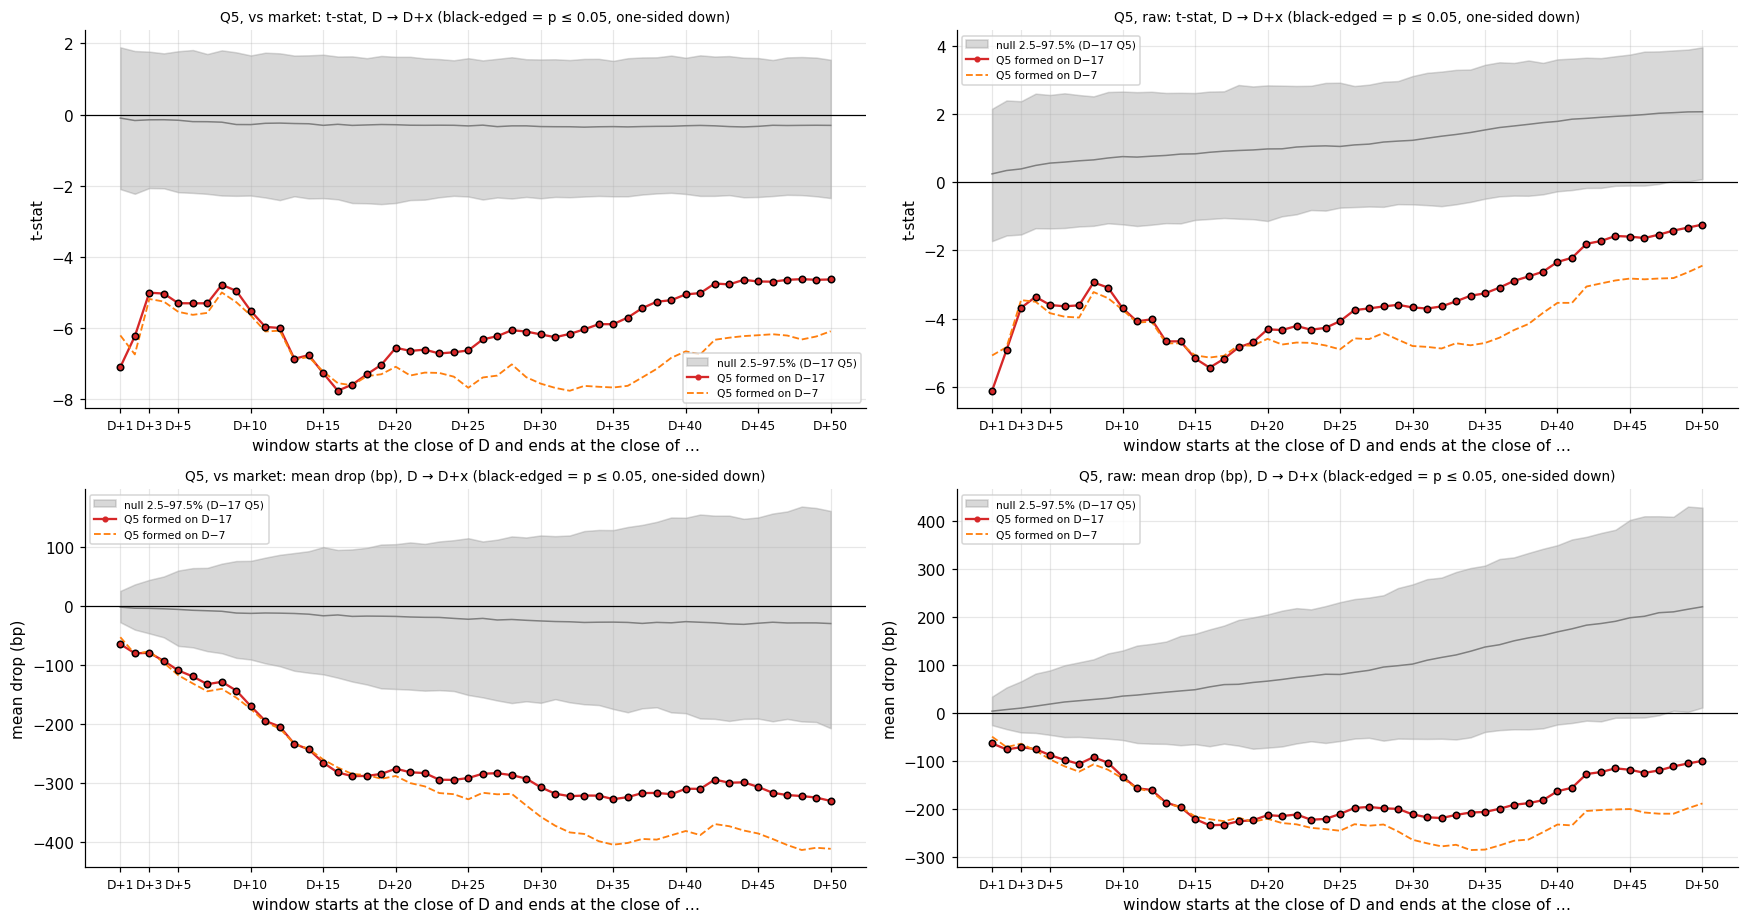


==== Q5 formed on D-17, vs market
    mean_bp      t  null_t_median  null_t_2.5%      p  D-7 Q5 mean_bp  D-7 Q5 t
x                                                                              
1   -64.039 -7.107         -0.099       -2.098  0.001         -52.200    -6.214
2   -79.485 -6.238         -0.167       -2.228  0.001         -80.506    -6.749
3   -78.790 -5.011         -0.147       -2.068  0.001         -76.186    -5.190
4   -92.396 -5.038         -0.145       -2.075  0.001         -95.539    -5.263
5  -108.610 -5.309         -0.160       -2.185  0.001        -116.713    -5.552
6  -118.758 -5.312         -0.199       -2.204  0.001        -130.634    -5.636
8  -127.841 -4.791         -0.214       -2.278  0.001        -139.693    -5.006
10 -169.119 -5.526         -0.282       -2.279  0.001        -173.801    -5.654
12 -203.717 -6.006         -0.240       -2.407  0.001        -206.933    -6.082
15 -264.937 -7.279         -0.303       -2.352  0.001        -259.533    -7.234
20 -2

In [10]:
XL = 50
XS_L = np.arange(1, XL + 1)
okL = TRADED[D, J] & (D + XL + 1 < T)
okL[okL] &= TRADED[D[okL] + XL, J[okL]]
s7 = D - 7
dtc7 = SB.values[s7, J] / ADV.values[s7, J]
has7 = (SB.values[s7, J] > 0) & np.isfinite(dtc7)
q7 = pd.Series(np.nan, index=ev.index)
q7[has7] = pd.Series(dtc7[has7], index=ev.index[has7]).groupby(ev.year[has7]).transform(quint)
q5_7 = (q7 == 5).values
print(f"Q5 on D-17: {q5m.sum()} events; Q5 on D-7: {q5_7.sum()}; overlap {(q5m & q5_7).sum()}")

VALID_L = TRADED & np.roll(TRADED, -XL, axis=0)
VALID_L[T - XL - 2:] = False
for d_, j_ in zip(D, J):
    VALID_L[max(d_ - 15 - XL, 0): min(d_ + XL + 1, T), j_] = False

resL = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {nm_: q5_t_all(CM, D, okL, XS_L, m_) for nm_, m_ in [("D-17", q5m), ("D-7", q5_7)]}
    null = {nm_: (np.empty((N_T_BOOT, XL)), np.empty((N_T_BOOT, XL))) for nm_ in real}
    for b in range(N_T_BOOT):
        S = random_starts(XL, 15, XL)[coh_idx]
        v_ = VALID_L[S, J]
        for nm_, m_ in [("D-17", q5m), ("D-7", q5_7)]:
            null[nm_][0][b], null[nm_][1][b] = q5_t_all(CM, S, v_, XS_L, m_)
    resL[kind] = (real, null)

fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
for c_, kind in enumerate(["vs market", "raw"]):
    real, null = resL[kind]
    for r_, (i_, ylab, scale) in enumerate([(0, "t-stat", 1), (1, "mean drop (bp)", 1e4)]):
        a = axes[r_, c_]
        nl = null["D-17"][i_] * scale
        lo, md_, hi = np.percentile(nl, [2.5, 50, 97.5], axis=0)
        a.fill_between(XS_L, lo, hi, color="C7", alpha=.3, label="null 2.5–97.5% (D−17 Q5)")
        a.plot(XS_L, md_, color="C7", lw=1)
        rl = real["D-17"][i_] * scale
        a.plot(XS_L, rl, "o-", ms=3, color="C3", label="Q5 formed on D−17")
        a.plot(XS_L, real["D-7"][i_] * scale, "--", color="C1", lw=1.2, label="Q5 formed on D−7")
        p_ = ((null["D-17"][i_] * scale <= rl).sum(0) + 1) / (N_T_BOOT + 1)
        sig_ = p_ <= 0.05
        a.scatter(XS_L[sig_], rl[sig_], s=18, color="C3", edgecolor="k", zorder=5)
        a.axhline(0, color="k", lw=.8)
        ticks = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
        a.set_xticks(ticks); a.set_xticklabels([f"D+{t}" for t in ticks], fontsize=8)
        a.set_xlabel("window starts at the close of D and ends at the close of …"); a.set_ylabel(ylab)
        a.set_title(f"Q5, {kind}: {ylab}, D → D+x (black-edged = p ≤ 0.05, one-sided down)", fontsize=9); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

for kind in resL:
    real, null = resL[kind]
    tr_, mu_ = real["D-17"]; nt = null["D-17"][0]
    tb = pd.DataFrame({"mean_bp": mu_ * 1e4, "t": tr_, "null_t_median": np.median(nt, 0), "null_t_2.5%": np.percentile(nt, 2.5, 0),
                       "p": ((nt <= tr_).sum(0) + 1) / (N_T_BOOT + 1), "D-7 Q5 mean_bp": real["D-7"][1] * 1e4,
                       "D-7 Q5 t": real["D-7"][0]}, index=pd.Index(XS_L, name="x"))
    print(f"\n==== Q5 formed on D-17, {kind}")
    print(tb.loc[[1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]].round(3).to_string())

**Interpretation.**
- **The drop keeps going for about 7 weeks.** Q5 vs market reaches −265bp at D+15, −291bp at D+25, −307bp at D+30 and
  −327bp at D+35, then flattens (−330bp at D+50). Every x from 1 to 50 is beyond all 1,000 null windows. The t-stat
  is largest at the two ends of the useful range: **−7.1 at D+1** and **−7.3 at D+15**.
- **A fresher signal (Q5 on D−7) makes the long tail bigger**: −357bp at D+30, −404bp at D+35 (t ≈ −7.6), with the
  same first-day drop. Stocks still heavily shorted a week before the deadline are the ones that keep falling.
- In raw returns the drop peaks around D+15 to D+35 (−210 to −220bp) and then partly recovers as the market rises.
  So beyond ~D+35 an unhedged short gives back money to the market.
- Beyond ~D+20 this overlaps with the same stock's next deadline (AGM → ex-dividend), and with a known anomaly (heavily
  shorted stocks underperform). The first 1–15 days are the part clearly tied to the deadline (see §5a).

### 4e. Day by day: is each single day's move significant?
**What this does.** Sections 4c–4d plot the *cumulative* drop from D to D+x, so once the price has fallen, every longer
window still contains that fall. Here each point is the Q5 portfolio's return **on that day alone**, against 1,000
cohort-level random windows at the same offset. That shows on which days after D the price is still falling
significantly. Solid: Q5 formed on D−17. Dashed: Q5 formed on D−7.

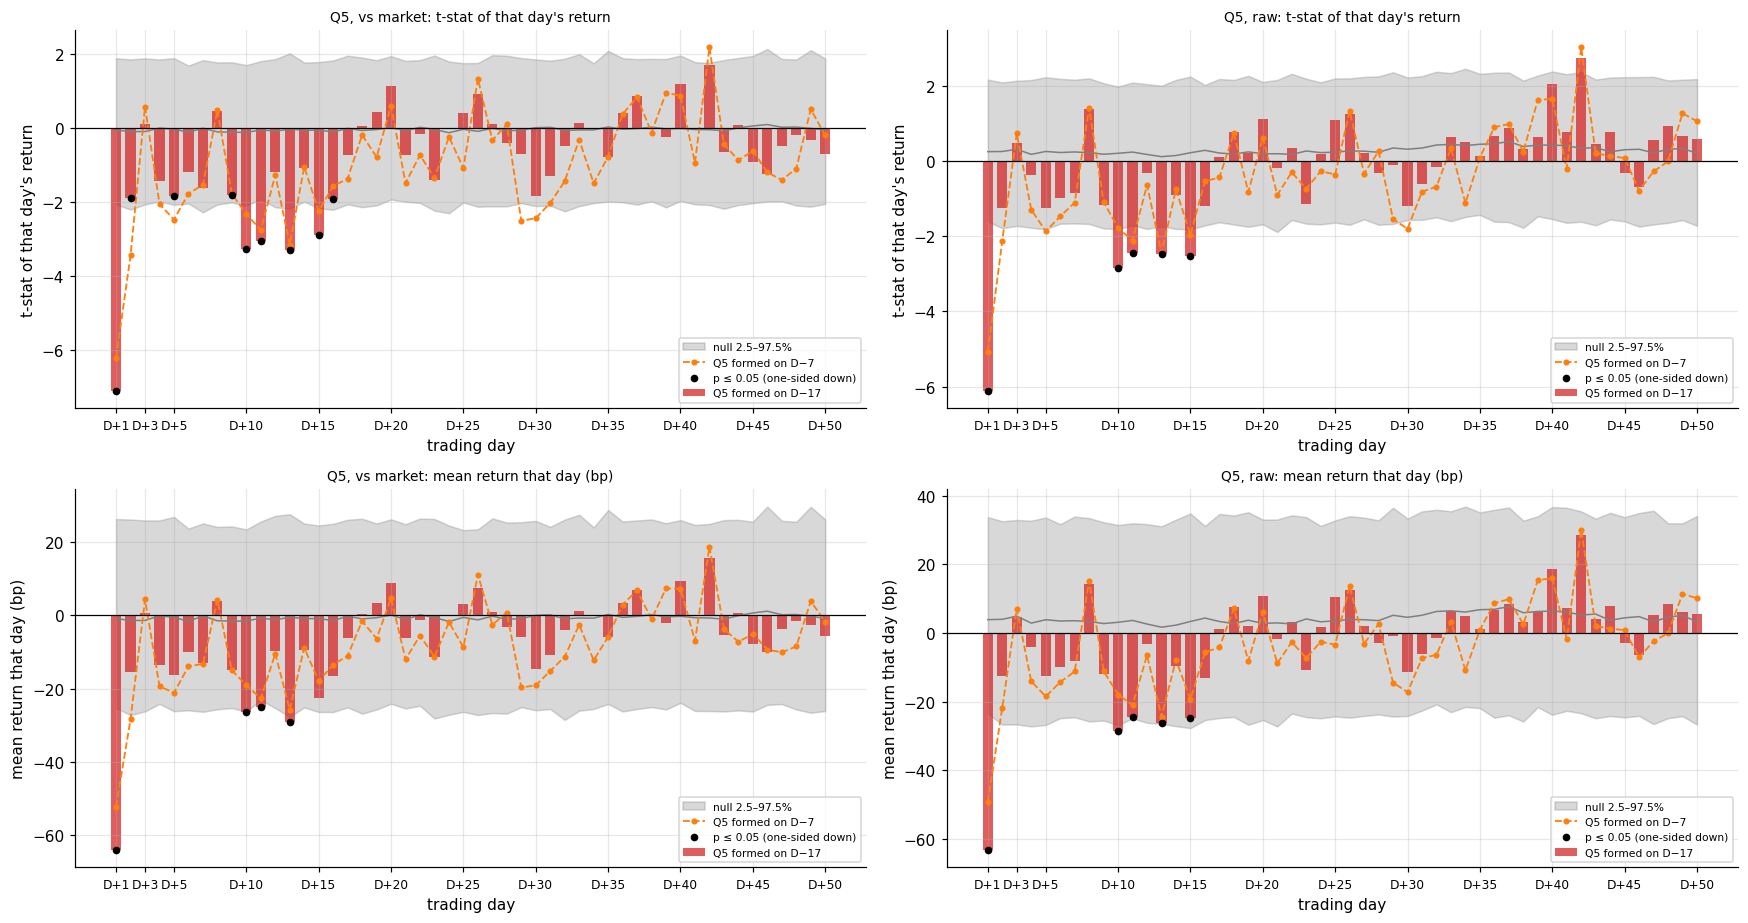


==== Q5 single-day returns, vs market (p one-sided: real <= null)
     D-17 bp  D-17 t  D-17 p  D-7 bp  D-7 t  D-7 p
day                                               
1    -64.039  -7.107   0.001 -52.200 -6.214  0.001
2    -15.446  -1.891   0.048 -28.306 -3.449  0.004
3      0.695   0.090   0.578   4.320  0.570  0.749
4    -13.606  -1.451   0.078 -19.353 -2.061  0.022
5    -16.214  -1.836   0.045 -21.173 -2.483  0.005
6    -10.149  -1.211   0.135 -13.921 -1.781  0.044
7    -13.034  -1.621   0.065 -13.266 -1.543  0.077
8      3.952   0.455   0.718   4.206  0.470  0.686
9    -14.825  -1.808   0.044 -15.013 -1.788  0.051
10   -26.453  -3.288   0.004 -19.095 -2.338  0.020
11   -24.944  -3.066   0.003 -22.690 -2.764  0.006
12    -9.654  -1.198   0.142 -10.441 -1.277  0.115
13   -29.206  -3.293   0.002 -25.754 -3.161  0.002
14    -9.441  -1.079   0.149  -8.856 -1.060  0.144
15   -22.574  -2.909   0.007 -17.989 -2.254  0.017
16   -16.515  -1.915   0.047 -13.502 -1.578  0.076
17    -6.150  -

In [11]:
OFFS = np.arange(1, XL + 1)                  # days D+1 .. D+50
def day_t(CM, S, valid, mask):
    t_, mu = np.empty(len(OFFS)), np.empty(len(OFFS))
    for k, o in enumerate(OFFS):
        v = CM[np.minimum(S + o + 1, T), J] - CM[np.minimum(S + o, T), J]
        t_[k], mu[k], _ = tstat(coh_mean(v, valid & mask))
    return t_, mu

resD = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {nm_: day_t(CM, D, okL, m_) for nm_, m_ in [("D-17", q5m), ("D-7", q5_7)]}
    null = {nm_: (np.empty((N_T_BOOT, len(OFFS))), np.empty((N_T_BOOT, len(OFFS)))) for nm_ in real}
    for b in range(N_T_BOOT):
        S = random_starts(XL, 15, XL)[coh_idx]
        v_ = VALID_L[S, J]
        for nm_, m_ in [("D-17", q5m), ("D-7", q5_7)]:
            null[nm_][0][b], null[nm_][1][b] = day_t(CM, S, v_, m_)
    resD[kind] = (real, null)

fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
for c_, kind in enumerate(["vs market", "raw"]):
    real, null = resD[kind]
    for r_, (i_, ylab, scale) in enumerate([(0, "t-stat of that day's return", 1), (1, "mean return that day (bp)", 1e4)]):
        a = axes[r_, c_]
        nl = null["D-17"][i_] * scale
        lo, md_, hi = np.percentile(nl, [2.5, 50, 97.5], axis=0)
        a.fill_between(OFFS, lo, hi, color="C7", alpha=.3, label="null 2.5–97.5%")
        a.plot(OFFS, md_, color="C7", lw=1)
        rl = real["D-17"][i_] * scale
        a.bar(OFFS, rl, color="C3", alpha=.75, width=.7, label="Q5 formed on D−17")
        a.plot(OFFS, real["D-7"][i_] * scale, "o--", ms=3, color="C1", lw=1.2, label="Q5 formed on D−7")
        p_lo = ((nl <= rl).sum(0) + 1) / (N_T_BOOT + 1)
        sig_ = p_lo <= 0.05
        a.scatter(OFFS[sig_], rl[sig_], s=16, color="k", zorder=5, label="p ≤ 0.05 (one-sided down)")
        a.axhline(0, color="k", lw=.8)
        ticks = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
        a.set_xticks(ticks); a.set_xticklabels([f"D+{t}" for t in ticks], fontsize=8)
        a.set_xlabel("trading day"); a.set_ylabel(ylab)
        a.set_title(f"Q5, {kind}: {ylab}", fontsize=9); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

for kind in resD:
    real, null = resD[kind]
    rows = []
    for nm_ in ["D-17", "D-7"]:
        t_, mu_ = real[nm_]; nt = null[nm_][0]
        p_ = ((nt <= t_).sum(0) + 1) / (N_T_BOOT + 1)
        rows.append(pd.DataFrame({f"{nm_} bp": mu_ * 1e4, f"{nm_} t": t_, f"{nm_} p": p_}, index=pd.Index(OFFS, name="day")))
    tb = pd.concat(rows, axis=1)
    print(f"\n==== Q5 single-day returns, {kind} (p one-sided: real <= null)")
    print(tb.loc[list(range(1, 21))].round(3).to_string())
    for nm_ in ["D-17", "D-7"]:
        sub = tb[f"{nm_} p"]
        print(f"  {nm_}: days with p <= 0.05: {[int(d) for d in sub.index[sub <= 0.05]]}")

**Interpretation.**
- **D+1 is by far the biggest day: −64bp (t = −7.1) vs market**, beyond every null draw. Nothing else is close. It
  happens while the ban is still on, so it is the removed buying, not new short selling.
- **D+2 to D+8 add a little:** −10 to −16bp a day, only D+2 and D+5 marginally significant (p ≈ 0.05). D+3 and D+8 are flat.
- **A second significant leg runs from D+9 to D+16:** D+10 −26bp (t = −3.3), D+11 −25bp (t = −3.1), D+13 −29bp
  (t = −3.3), D+15 −23bp (t = −2.9), and D+9, D+16 around −15bp (p ≈ 0.045). This overlaps the period when the short book
  rebuilds (28% of the pre-ban level on D+4 → 80% on D+15).
- **After D+17 the signal is gone.** Daily returns scatter around zero inside the null band, which is what 4d's flat
  cumulative line beyond ~D+35 implied. With 50 days tested, the odd isolated "significant" day later on (e.g. D+29–31
  for the D−7 Q5) is what chance produces.
- **Trading implication:** the payoff is two short bursts. The biggest is the first day (short at the close of D, cover
  at the close of D+1). A second, smaller one comes around D+9 to D+16. Holding through D+3 to D+8 earns little per day.

### 4f. Overlap-robust tests
**Why.** Sections 4–4e give each deadline date one observation. But deadlines cluster in AGM season (May–June) and
dividend season (July–August), so the D → D+x windows of nearby dates share most of their days. The t-stats treat them
as independent, and the random-window nulls draw independent windows, so both overstate significance, more so for long x.
Four tests that do not have this problem:

1. **Calendar-time portfolio.** On every trading day, hold (equal-weighted) every Q5 stock that is inside its own
   [D+a, D+b] window, and record that day's return vs the market. Each calendar day appears once, so nothing is
   double-counted. t-stats are Newey-West with lag = window length.
2. **Against ordinary heavily shorted stocks.** Heavily shorted stocks tend to underperform on any day (the short
   sellers are partly right). The control portfolio holds, each day, the top 20% of stocks by days-to-cover (measured
   17 days earlier) that are **not** within 25 days of their own deadline. Q5-after-D minus that control is the part
   that belongs to the deadline.
3. **Year-block shift permutation.** Keep the same Q5 stocks and the same spacing between deadlines, but slide every
   deadline in a year by one common random offset (±20 to ±60 trading days). That preserves the seasonal clustering
   exactly. 500 draws.
4. **Panel regression.** Every stock-day with short interest, daily return vs market (bp) on indicators for D+1 and
   D+2…D+15 of a Q5 event, D−5…D of a Q5 event (the climb), D+1…D+15 of any event (a generic post-deadline effect),
   and log days-to-cover 17 days earlier (the short-interest anomaly). Stock and date fixed effects; standard errors
   clustered by date **and** by stock.

In [12]:
import statsmodels.api as sm
LRX = np.diff(C_EW, axis=0) * 1e4                # daily log return vs market, bp
LRX[~TRADED] = np.nan
q1 = (grp == "Q1")

def win_mask(Dv, Jv, a, b):
    W = np.zeros((T, N), bool)
    for d_, j_ in zip(Dv, Jv):
        W[max(d_ + a, 0): min(d_ + b + 1, T), j_] = True
    return W

def ctp(W):                                      # calendar-time portfolio: one return per trading day
    with np.errstate(all="ignore"):
        return np.nanmean(np.where(W, LRX, np.nan), 1)

def nw(s, lag):
    s = np.asarray(s); s = s[np.isfinite(s)]
    f = sm.OLS(s, np.ones(len(s))).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    return f.params[0], f.tvalues[0], len(s)

# control: top-20% days-to-cover (17-day lag), not within 25 days of own deadline
DTCL = np.full((T, N), np.nan); DTCL[SIG_LAG:] = (SB.values / ADV.values)[:-SIG_LAG]
elig = (DTCL > 0) & ~win_mask(D, J, -25, 25) & TRADED
ctrl = ctp(pd.DataFrame(np.where(elig, DTCL, np.nan)).rank(axis=1, pct=True).values > 0.8)
m_, t_, _ = nw(ctrl, 5)
print(f"control (heavily shorted, no deadline nearby): {m_:.1f} bp/day vs market, t = {t_:.2f}\n")

WINS = [(1, 1), (2, 5), (1, 5), (6, 15), (1, 15), (16, 30), (31, 50)]
rows = []
for a, b in WINS:
    p5 = ctp(win_mask(D[q5], J[q5], a, b)); p1 = ctp(win_mask(D[q1], J[q1], a, b)); L = b - a + 1
    (m5, t5, n5), (m1, t1, _), (md, td, _), (mc, tc, _) = nw(p5, L), nw(p1, L), nw(p5 - p1, L), nw(p5 - ctrl, L)
    rows.append({"window": f"D+{a}..D+{b}", "days": n5, "Q5 bp/day": m5, "Q5 t": t5, "Q1 bp/day": m1, "Q1 t": t1,
                 "Q5−Q1 bp/day": md, "Q5−Q1 t": td, "Q5−control bp/day": mc, "Q5−control t": tc,
                 "Q5 cum bp": m5 * L, "Q5−control cum bp": mc * L})
ct = pd.DataFrame(rows).set_index("window")
print("Calendar-time portfolios (return vs market; Newey-West t)")
print(ct.round(2).to_string())

control (heavily shorted, no deadline nearby): -9.1 bp/day vs market, t = -4.55

Calendar-time portfolios (return vs market; Newey-West t)
            days  Q5 bp/day  Q5 t  Q1 bp/day  Q1 t  Q5−Q1 bp/day  Q5−Q1 t  Q5−control bp/day  Q5−control t  Q5 cum bp  Q5−control cum bp
window                                                                                                                                  
D+1..D+1     685     -62.20 -6.73       4.23  0.75        -79.45    -6.23             -47.51         -4.81     -62.20             -47.51
D+2..D+5    1395      -7.89 -1.35      -5.76 -1.55         -7.25    -1.18               5.13          0.81     -31.54              20.51
D+1..D+5    1507     -16.93 -3.24      -3.75 -1.14        -20.09    -3.68              -5.13         -0.90     -84.67             -25.63
D+6..D+15   1809     -13.26 -2.92      -8.97 -2.95         -9.28    -1.98              -3.83         -0.78    -132.56             -38.26
D+1..D+15   1945     -14.73 -3.79      

In [13]:
# 3. year-block shift permutation
yrs = ev.year.values
def ctp_mean(Dv, a, b):
    ok = q5 & (Dv + a >= 0) & (Dv + b < T)
    return np.nanmean(ctp(win_mask(Dv[ok], J[ok], a, b)))
SHIFTS = np.r_[-60:-19, 20:61]
N_PERM = 500
perm, perm_null = {}, {}
for a, b in [(1, 1), (1, 5), (1, 15), (2, 15)]:
    real = ctp_mean(D, a, b)
    nul = np.empty(N_PERM)
    for i in range(N_PERM):
        Ds = D.copy()
        for y in np.unique(yrs):
            Ds[yrs == y] += rng.choice(SHIFTS)
        nul[i] = ctp_mean(Ds, a, b)
    perm_null[f"D+{a}..D+{b}"] = nul
    perm[f"D+{a}..D+{b}"] = {"real bp/day": real, "null mean": nul.mean(), "null 2.5%": np.percentile(nul, 2.5),
                             "p (one-sided)": (np.sum(nul <= real) + 1) / (N_PERM + 1)}
print("Year-block shift permutation (same stocks, same seasonal clustering)")
print(pd.DataFrame(perm).T.round(3).to_string())

Year-block shift permutation (same stocks, same seasonal clustering)
           real bp/day  null mean  null 2.5%  p (one-sided)
D+1..D+1       -62.197     -2.592    -19.068          0.002
D+1..D+5       -16.934     -1.413    -11.881          0.002
D+1..D+15      -14.711     -1.662     -8.488          0.002
D+2..D+15      -10.386     -1.526     -8.389          0.010


In [14]:
# 4. panel regression: stock + date fixed effects, two-way clustered SEs
post1 = win_mask(D[q5], J[q5], 1, 1); post2 = win_mask(D[q5], J[q5], 2, 15)
pre5 = win_mask(D[q5], J[q5], -5, 0); anyev = win_mask(D, J, 1, 15)
m = TRADED & (DTCL > 0) & np.isfinite(LRX)
tt, jj = np.nonzero(m)
X = pd.DataFrame({"ret_bp": LRX[m], "Q5: D+1": post1[m], "Q5: D+2..D+15": post2[m], "Q5: D−5..D": pre5[m],
                  "any event: D+1..D+15": anyev[m], "log days-to-cover (lag 17)": np.log(DTCL[m])}).astype(float)
for _ in range(10):                              # absorb date and stock fixed effects (alternating projections)
    X = X - X.groupby(tt).transform("mean"); X = X - X.groupby(jj).transform("mean")
fit = sm.OLS(X.ret_bp, X.drop(columns="ret_bp")).fit(cov_type="cluster", cov_kwds={"groups": np.c_[tt, jj]})
print(f"Panel: {len(X):,} stock-days; daily return vs market (bp); stock + date FE; clustered by date and stock")
print(pd.DataFrame({"coef bp/day": fit.params, "t": fit.tvalues, "p": fit.pvalues}).round(3).to_string())

Panel: 1,340,108 stock-days; daily return vs market (bp); stock + date FE; clustered by date and stock
                            coef bp/day      t      p
Q5: D+1                         -47.705 -7.641  0.000
Q5: D+2..D+15                    -7.539 -3.346  0.001
Q5: D−5..D                       11.468  4.239  0.000
any event: D+1..D+15             -5.107 -5.211  0.000
log days-to-cover (lag 17)       -1.445 -6.399  0.000


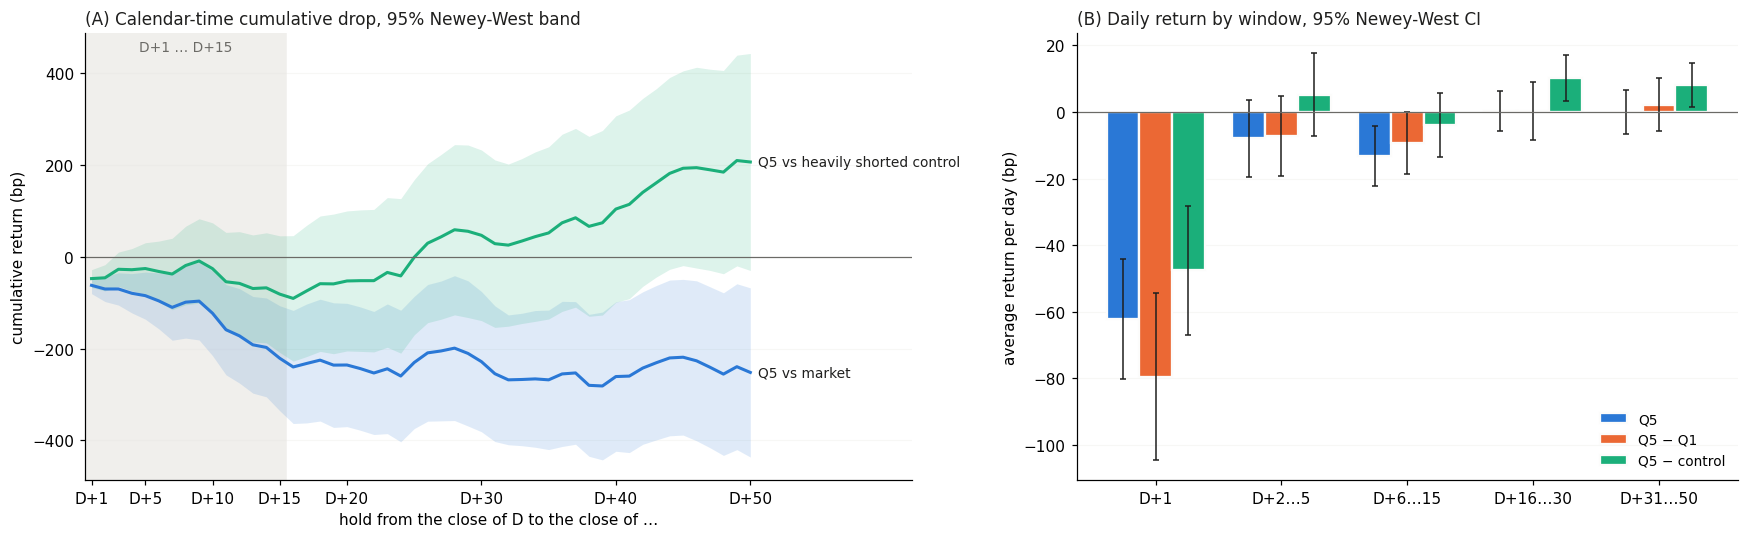

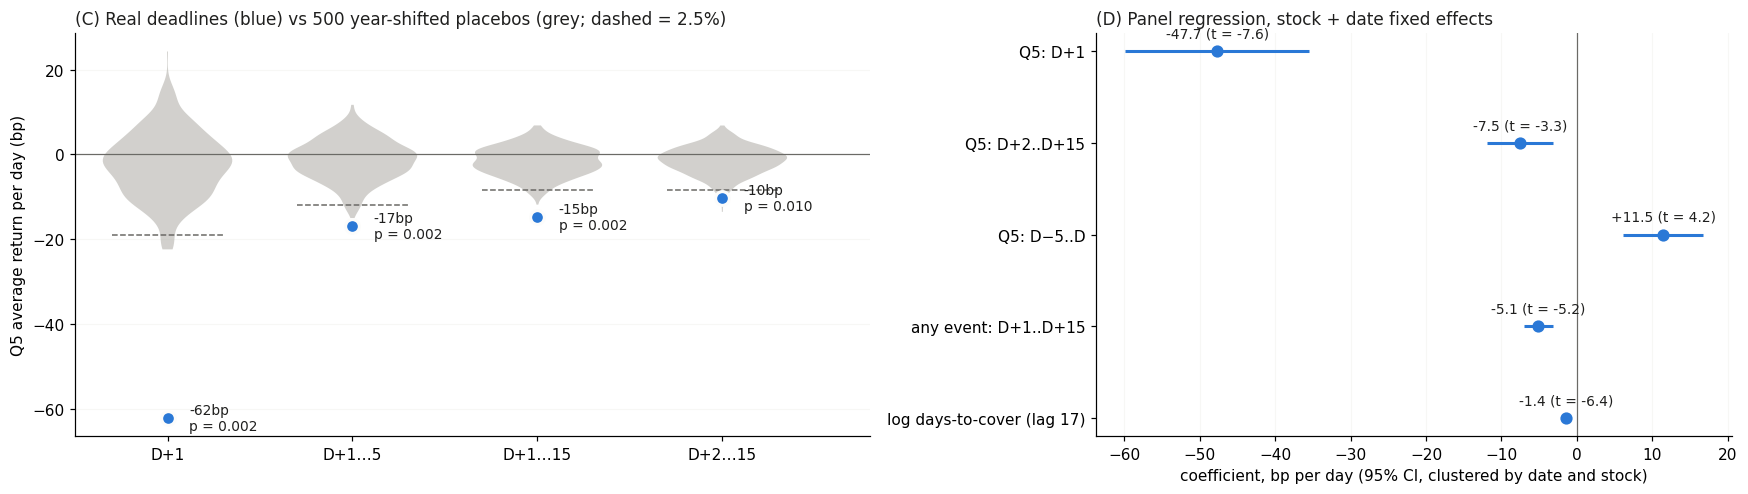

In [15]:
# --- figures for 4f ---
BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#1f1f1e", "#6b6a66", "#e6e5e1"
def style(a):
    a.grid(False); a.grid(axis="y", color=GRID, lw=.8); a.set_axisbelow(True)
    for sp in ("top", "right"): a.spines[sp].set_visible(False)
    a.axhline(0, color=MUTED, lw=.8)
def nw_se(s, lag):
    s = np.asarray(s); s = s[np.isfinite(s)]
    f = sm.OLS(s, np.ones(len(s))).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    return f.params[0], f.bse[0]

# (A) cumulative drop, calendar-time: mean daily return over D+1..D+x (Newey-West) times x
XC = np.arange(1, 51)
cum = {"Q5 vs market": [], "Q5 vs heavily shorted control": []}
for x in XC:
    p5 = ctp(win_mask(D[q5], J[q5], 1, x))
    for nm_, s_ in [("Q5 vs market", p5), ("Q5 vs heavily shorted control", p5 - ctrl)]:
        mu_, se_ = nw_se(s_, x); cum[nm_].append((mu_ * x, se_ * x))

# (B) bp/day by window with 95% CI
BW = [(1, 1), (2, 5), (6, 15), (16, 30), (31, 50)]
bars = {"Q5": [], "Q5 − Q1": [], "Q5 − control": []}
for a, b in BW:
    p5 = ctp(win_mask(D[q5], J[q5], a, b)); p1 = ctp(win_mask(D[q1], J[q1], a, b)); L = b - a + 1
    for nm_, s_ in [("Q5", p5), ("Q5 − Q1", p5 - p1), ("Q5 − control", p5 - ctrl)]:
        bars[nm_].append(nw_se(s_, L))

fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.25, 1]})
a = ax[0]
for (nm_, v), c in zip(cum.items(), [BLUE, AQUA]):
    v = np.array(v)
    a.fill_between(XC, v[:, 0] - 1.96 * v[:, 1], v[:, 0] + 1.96 * v[:, 1], color=c, alpha=.15, lw=0)
    a.plot(XC, v[:, 0], color=c, lw=2)
    a.text(XC[-1] + .6, v[-1, 0], nm_, color=INK, va="center", fontsize=9)
a.axvspan(.5, 15.5, color="#f0efec", zorder=0); a.text(8, a.get_ylim()[1] * .92 if a.get_ylim()[1] > 0 else 20, "D+1 … D+15", ha="center", color=MUTED, fontsize=9)
style(a); a.set_xlim(0.5, 62)
a.set_xticks([1, 5, 10, 15, 20, 30, 40, 50]); a.set_xticklabels([f"D+{t}" for t in [1, 5, 10, 15, 20, 30, 40, 50]])
a.set_xlabel("hold from the close of D to the close of …"); a.set_ylabel("cumulative return (bp)")
a.set_title("(A) Calendar-time cumulative drop, 95% Newey-West band", loc="left", fontsize=11, color=INK)

b = ax[1]
w = .26; xs = np.arange(len(BW))
for k, ((nm_, v), c) in enumerate(zip(bars.items(), [BLUE, ORANGE, AQUA])):
    v = np.array(v)
    b.bar(xs + (k - 1) * w, v[:, 0], w, color=c, edgecolor="#fcfcfb", lw=1.5, label=nm_)
    b.errorbar(xs + (k - 1) * w, v[:, 0], yerr=1.96 * v[:, 1], fmt="none", ecolor=INK, elinewidth=1, capsize=2)
style(b)
b.set_xticks(xs); b.set_xticklabels([f"D+{a_}" if a_ == b_ else f"D+{a_}…{b_}" for a_, b_ in BW])
b.set_ylabel("average return per day (bp)"); b.legend(frameon=False, fontsize=9, loc="lower right")
b.set_title("(B) Daily return by window, 95% Newey-West CI", loc="left", fontsize=11, color=INK)
plt.tight_layout(); plt.show()

# (C) permutation nulls and (D) panel coefficients
fig, ax = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
a = ax[0]
PW = [(1, 1), (1, 5), (1, 15), (2, 15)]
vals = [perm_null[f"D+{a_}..D+{b_}"] for a_, b_ in PW]
reals = [perm[f"D+{a_}..D+{b_}"]["real bp/day"] for a_, b_ in PW]
a.violinplot(vals, positions=range(len(PW)), showextrema=False, widths=.7)
for body in a.collections: body.set_facecolor("#b4b2ac"); body.set_alpha(.6)
for i_, (r_, nv) in enumerate(zip(reals, vals)):
    a.plot([i_ - .3, i_ + .3], [np.percentile(nv, 2.5)] * 2, color=MUTED, lw=1, ls="--")
    a.plot(i_, r_, "o", ms=9, color=BLUE, mec="#fcfcfb", mew=2)
    a.annotate(f"{r_:.0f}bp\np = {perm[f'D+{PW[i_][0]}..D+{PW[i_][1]}']['p (one-sided)']:.3f}", (i_, r_),
               textcoords="offset points", xytext=(14, 0), va="center", fontsize=9, color=INK)
style(a); a.set_xticks(range(len(PW))); a.set_xticklabels([f"D+{a_}" if a_ == b_ else f"D+{a_}…{b_}" for a_, b_ in PW])
a.set_xlim(-.5, len(PW) - .2); a.set_ylabel("Q5 average return per day (bp)")
a.set_title(f"(C) Real deadlines (blue) vs {N_PERM} year-shifted placebos (grey; dashed = 2.5%)", loc="left", fontsize=11, color=INK)

b = ax[1]
co = pd.DataFrame({"c": fit.params, "se": fit.bse})[::-1]
yy = np.arange(len(co))
b.errorbar(co.c, yy, xerr=1.96 * co.se, fmt="o", color=BLUE, ecolor=BLUE, ms=7, elinewidth=2, capsize=0)
for y_, (c_, t_) in enumerate(zip(co.c, fit.tvalues[::-1])):
    b.annotate(f"{c_:+.1f} (t = {t_:.1f})", (c_, y_), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=INK)
b.axvline(0, color=MUTED, lw=.8); b.set_yticks(yy); b.set_yticklabels(co.index)
b.grid(False); b.grid(axis="x", color=GRID, lw=.8)
for sp in ("top", "right"): b.spines[sp].set_visible(False)
b.set_xlabel("coefficient, bp per day (95% CI, clustered by date and stock)")
b.set_title("(D) Panel regression, stock + date fixed effects", loc="left", fontsize=11, color=INK)
plt.tight_layout(); plt.show()

**Interpretation.**
*(numbers below are from the run on 2026-09-26; see the printed tables)*
- **D+1 survives every test.** Calendar-time Q5 −62bp that day (t = −6.7); −48bp beyond ordinary heavily shorted stocks
  (t = −4.8); −48bp in the panel with stock and date fixed effects and two-way clustering (t = −7.6); and more extreme
  than every year-shifted placebo.
- **D+2 to D+15 is real but smaller than 4d suggested.** In the panel it is −7.5bp/day beyond the short-interest
  anomaly (t = −3.3, about −105bp over the 14 days), and Q5 − Q1 is −13bp/day (t = −2.7). But against the control of
  heavily shorted stocks with no deadline nearby, the gap is only −5bp/day (t ≈ −1.3). Part of the post-deadline drift
  is simply that heavily shorted stocks underperform on any day (control: about −9bp/day vs the market).
- **After D+15 there is nothing.** D+16…D+30 and D+31…D+50 are ≈ 0bp/day in calendar time (t ≈ 0). The significant
  t-stats out to D+50 in 4d come from carrying the first two weeks forward in a cumulative window, inflated by
  overlapping windows. They should not be read as a 50-day effect.
- **Figure A** is the robust version of 4d: the blue line (Q5 vs market) falls about −220bp by D+15 and then goes
  flat, with a 95% band that no longer hugs the line at long horizons. The green line (Q5 minus ordinary heavily
  shorted stocks) is below zero only through about D+15; after that it *rises*, because the control keeps drifting down
  (about −9bp/day) while Q5 stops. **Figure B** shows the same by window: only D+1 is clearly below zero for all three
  comparisons. **Figure C**: the real deadline beats all 500 year-shifted placebos for D+1, D+1…5 and D+1…15, and 99% of them
  for D+2…15 (p = 0.01). **Figure D**: the
  panel coefficients, with the pre-deadline climb (+11bp/day, D−5…D) shown for contrast.
- **Bottom line.** The robust, deadline-specific part of the drop is the first day after D (about −50 to −60bp) plus a
  smaller drift over the next two weeks. That matches 4e's day-by-day result and the trade in §6 (short at the close
  of D).

### 4g. Rolling 5-day windows: when after D is there still a drop?
**Why.** Every window in 4c–4d starts at D, so the large first-day move (D+1) sits inside all of them and keeps the
t-stat negative no matter how far out the window ends. Here each point is a **fixed 5-day hold that starts x days after
D**: from the close of D+x to the close of D+x+5, for x = 0…45. The x = 0 point contains D+1; from x = 1 on, D+1 is
excluded, and from x = 5 on, the windows share no days with the first week.

Same machinery as 4c/4d: one equal-weighted Q5 portfolio (formed on D−17) per deadline date, t-stat across dates, and
1,000 null draws in which every deadline cohort gets one random start from the same stocks, away from their own
deadlines, with the same 5-day window at the same offset. Black-edged = p ≤ 0.05, one-sided (real ≤ null).

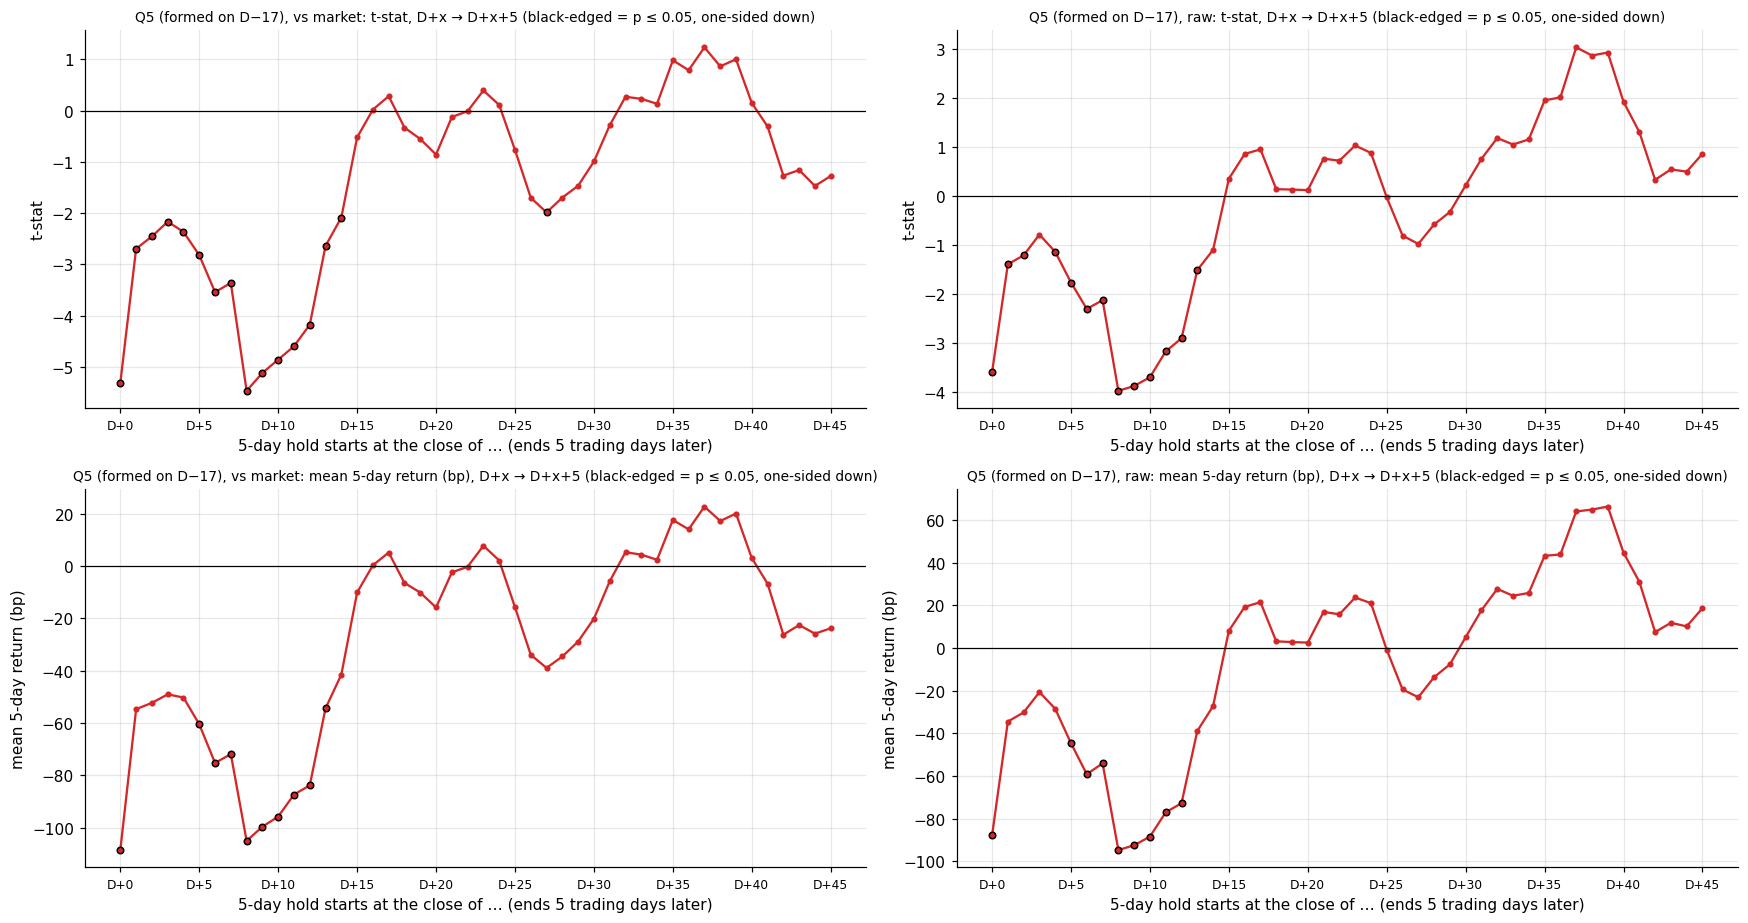


==== rolling 5-day, Q5 formed on D-17, vs market
       window  mean_bp      t  null_t_median  null_t_2.5%      p
x                                                               
0     D+0→D+5 -108.610 -5.309         -0.147       -2.098  0.001
1     D+1→D+6  -54.720 -2.694         -0.145       -2.281  0.010
2     D+2→D+7  -52.308 -2.454         -0.145       -2.293  0.017
3     D+3→D+8  -49.051 -2.167         -0.196       -2.267  0.031
4     D+4→D+9  -50.270 -2.364         -0.157       -2.359  0.025
5    D+5→D+10  -60.509 -2.819         -0.216       -2.129  0.011
6    D+6→D+11  -75.304 -3.539         -0.205       -2.205  0.002
8    D+8→D+13 -105.082 -5.462         -0.205       -2.267  0.001
10  D+10→D+15  -95.818 -4.854         -0.121       -2.262  0.001
12  D+12→D+17  -83.885 -4.175         -0.055       -2.371  0.001
15  D+15→D+20  -10.075 -0.523         -0.124       -2.197  0.352
20  D+20→D+25  -15.815 -0.858         -0.129       -2.179  0.238
25  D+25→D+30  -15.714 -0.769         -0

In [16]:
HOLD = 5
XR = np.arange(0, XL - HOLD + 1)                          # start offsets D+0 .. D+45

def roll_t(CM, S, valid, mask):
    a_ = (S + 1)[:, None] + XR[None, :]
    cl = CM[np.minimum(a_ + HOLD, T), J[:, None]] - CM[np.minimum(a_, T), J[:, None]]
    t_, mu = np.empty(len(XR)), np.empty(len(XR))
    for k in range(len(XR)):
        t_[k], mu[k], _ = tstat(coh_mean(cl[:, k], valid & mask))
    return t_, mu

resR = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = roll_t(CM, D, okL, q5m)
    nt, nm = np.empty((N_T_BOOT, len(XR))), np.empty((N_T_BOOT, len(XR)))
    for b in range(N_T_BOOT):
        S = random_starts(XL, 15, XL)[coh_idx]
        nt[b], nm[b] = roll_t(CM, S, VALID_L[S, J], q5m)
    resR[kind] = (real, (nt, nm))

fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
for c_, kind in enumerate(["vs market", "raw"]):
    real, null = resR[kind]
    for r_, (i_, ylab, scale) in enumerate([(0, "t-stat", 1), (1, "mean 5-day return (bp)", 1e4)]):
        a = axes[r_, c_]
        rl = real[i_] * scale
        p_ = ((null[i_] * scale <= rl).sum(0) + 1) / (N_T_BOOT + 1)
        a.plot(XR, rl, "o-", ms=3, color="C3")
        sig_ = p_ <= 0.05
        a.scatter(XR[sig_], rl[sig_], s=18, color="C3", edgecolor="k", zorder=5)
        a.axhline(0, color="k", lw=.8)
        ticks = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
        a.set_xticks(ticks); a.set_xticklabels([f"D+{t}" for t in ticks], fontsize=8)
        a.set_xlabel("5-day hold starts at the close of … (ends 5 trading days later)"); a.set_ylabel(ylab)
        a.set_title(f"Q5 (formed on D−17), {kind}: {ylab}, D+x → D+x+5 (black-edged = p ≤ 0.05, one-sided down)", fontsize=9)
plt.tight_layout(); plt.show()

for kind in resR:
    (tr_, mu_), (nt, nm) = resR[kind]
    tb = pd.DataFrame({"window": [f"D+{x}→D+{x + HOLD}" for x in XR], "mean_bp": mu_ * 1e4, "t": tr_,
                       "null_t_median": np.median(nt, 0), "null_t_2.5%": np.percentile(nt, 2.5, 0),
                       "p": ((nt <= tr_).sum(0) + 1) / (N_T_BOOT + 1)}, index=pd.Index(XR, name="x"))
    print(f"\n==== rolling {HOLD}-day, Q5 formed on D-17, {kind}")
    print(tb.loc[[0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45]].round(3).to_string())

**Interpretation.**
- **Two separate legs, then nothing.** Against the market, the 5-day hold starting at the close of D loses −109bp
  (t = −5.3). Excluding D+1, holds starting D+1 to D+5 still lose about −50 to −60bp (t ≈ −2.2 to −2.8, p = 0.01–0.03).
  A second, stronger leg follows: holds starting **D+8 to D+12 lose −84 to −105bp (t = −4.2 to −5.5, p = 0.001)**,
  which is when margin shorting has reopened and the short book is rebuilding (28% of its pre-ban level on D+4, 80% by
  D+15).
- **From D+15 on, the drop is gone.** Holds starting D+15 or later are within ±25bp and inside the null (t between −1.3
  and +1.2). The one black dot near D+27 is what 46 overlapping tests produce by chance. So the significance out to
  D+50 in 4d was the first two weeks carried forward, not a 50-day effect.
- **Raw** (unhedged) gives the same shape: −88bp for D→D+5 (t = −3.6), −73 to −95bp for holds starting D+8 to D+12,
  and nothing after D+15. The raw null sits above zero (the market rises), so smaller raw losses are still significant.
- **Note:** neighbouring points share 4 of their 5 days, so the line is smooth by construction. Points 5 apart
  (D+0, D+5, D+10, D+15, …) use disjoint days and can be read as independent checks.
- **For the trade:** the edge is the first ~2.5 weeks after D, in two bursts: short at the close of D, and again
  around D+8 to D+12. Nothing is gained by holding past D+15.

## 5. Is it these dates? A stress test
**What this does.** (a) **Calendar shift**: the same Q5 and Q1 stocks, with the window starting k = −40…+40 trading
days from D, for drop(5) and drop(10). The real start (k = 0) should be the most negative. (b) **Ex-dividend check**:
repeat the key numbers with every ex-date's return removed. (c) **Heavy tails**: trimmed, winsorised and median
versions and a sign test. (d) **Give-back**: does the drop scale with how much the stock climbed into D (D−6 → D)?
Regression with short-pressure rank, the climb, size, prior 20-day momentum, year and reason, clustered by date.
(e) **Stability**: by year, reason, size, in-sample vs out-of-sample.

Q5-Q1 drop(5): real -99.1bp | other windows mean -12.0bp, range [-73.2, 38.8] | rank 1/81  ||  Q5 alone: real -113.4bp, others mean -15.9bp, rank 1/81, most negative other k = +2


Q5-Q1 drop(10): real -141.3bp | other windows mean -22.8bp, range [-126.8, 58.6] | rank 1/81  ||  Q5 alone: real -180.1bp, others mean -30.9bp, rank 1/81, most negative other k = +1


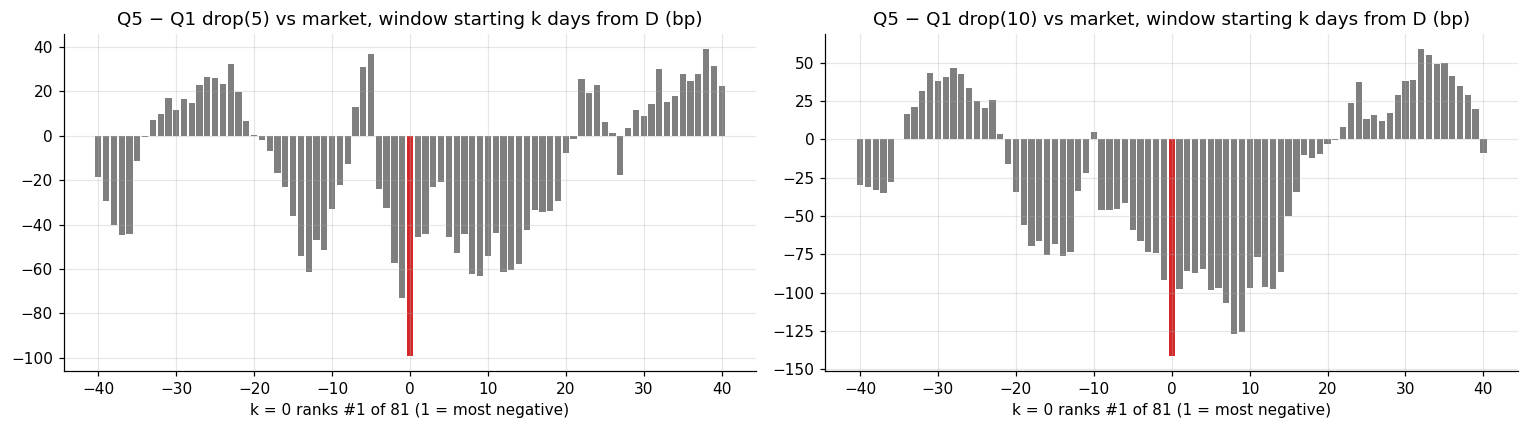


(b) ex-dividend check: Q5 and Q5-Q1 drop(x) vs market, with and without ex-date returns (date-clustered t)
  drop(3):  with ex-dates: Q5 -69.8bp (t=-6.31), Q5-Q1 -117.2bp (t=-5.77)  |  ex-dates removed: Q5 -69.0bp (t=-6.24), Q5-Q1 -115.7bp (t=-5.69)
  drop(5):  with ex-dates: Q5 -112.9bp (t=-7.67), Q5-Q1 -110.3bp (t=-4.46)  |  ex-dates removed: Q5 -110.7bp (t=-7.99), Q5-Q1 -119.3bp (t=-5.35)
  drop(10):  with ex-dates: Q5 -181.5bp (t=-7.49), Q5-Q1 -175.3bp (t=-4.98)  |  ex-dates removed: Q5 -179.0bp (t=-7.61), Q5-Q1 -184.3bp (t=-5.50)
  drop(15):  with ex-dates: Q5 -250.5bp (t=-8.77), Q5-Q1 -244.9bp (t=-5.52)  |  ex-dates removed: Q5 -248.1bp (t=-8.83), Q5-Q1 -253.9bp (t=-5.90)
  ex-dividend/rights events with an ex-date row in [D, D+10]: 98.8%; median ex-date offset 4 trading days


In [17]:
def shifted(k, x, g_, C=C_EW):
    m = (ev.grp == g_).values
    Sk, J_ = D[m] + k, J[m]
    ok = (Sk >= 0) & (Sk + x + 1 < T)
    Sk, J_ = Sk[ok], J_[ok]
    good = TRADED[Sk, J_] & TRADED[Sk + x, J_]
    return np.mean((C[Sk + 1 + x, J_] - C[Sk + 1, J_])[good]) * 1e4

ks = np.arange(-40, 41)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, x in zip(ax, [5, 10]):
    v = np.array([shifted(k, x, "Q5") - shifted(k, x, "Q1") for k in ks])
    a.bar(ks, v, color=np.where(ks == 0, "C3", "C7"))
    rank = int((v <= v[ks == 0][0]).sum())
    a.set_title(f"Q5 − Q1 drop({x}) vs market, window starting k days from D (bp)")
    a.set_xlabel(f"k = 0 ranks #{rank} of {len(ks)} (1 = most negative)")
    rest = np.delete(v, 40)
    q5 = np.array([shifted(k, x, "Q5") for k in ks]); r5 = int((q5 <= q5[40]).sum())
    print(f"Q5-Q1 drop({x}): real {v[40]:.1f}bp | other windows mean {rest.mean():.1f}bp, range [{rest.min():.1f}, {rest.max():.1f}] | rank {rank}/81"
          f"  ||  Q5 alone: real {q5[40]:.1f}bp, others mean {np.delete(q5, 40).mean():.1f}bp, rank {r5}/81, most negative other k = {ks[np.argmin(np.where(ks == 0, 1e9, q5))]:+d}")
plt.tight_layout(); plt.show()

print("\n(b) ex-dividend check: Q5 and Q5-Q1 drop(x) vs market, with and without ex-date returns (date-clustered t)")
CL_NOEX = drop(D, J, C_EW_NOEX); CL_NOEX[~ok_ev] = np.nan
for x in [3, 5, 10, 15]:
    out = []
    for lab_, M in [("with ex-dates", CL["vs market"]), ("ex-dates removed", CL_NOEX)]:
        m5, s5 = clustered_mean(M[q5m, x - 1], ev.Ddate.values[q5m])
        spread = pd.Series(M[q5m, x - 1]).groupby(ev.Ddate.values[q5m]).mean() - pd.Series(M[grp == "Q1", x - 1]).groupby(ev.Ddate.values[grp == "Q1"]).mean()
        spread = spread.dropna()
        out.append(f"{lab_}: Q5 {m5 * 1e4:+.1f}bp (t={m5 / s5:.2f}), Q5-Q1 {spread.mean() * 1e4:+.1f}bp (t={spread.mean() / spread.std() * np.sqrt(len(spread)):.2f})")
    print(f"  drop({x}):  " + "  |  ".join(out))
exdiv_ev = ev.why.isin(["ex-div", "ex-rights+div", "ex-rights"]).values
hit = np.array([EXDAY[d_:d_ + 11, j_].any() for d_, j_ in zip(D, J)])
print(f"  ex-dividend/rights events with an ex-date row in [D, D+10]: {hit[exdiv_ev].mean():.1%}; "
      f"median ex-date offset {np.median([np.argmax(EXDAY[d_:d_ + 11, j_]) for d_, j_ in zip(D[exdiv_ev & hit], J[exdiv_ev & hit])]):.0f} trading days")

In [18]:
tr = lambda s, q: s[(s > s.quantile(q)) & (s < s.quantile(1 - q))]
wz = lambda s, q: s.clip(s.quantile(q), s.quantile(1 - q))
for x in [5, 10]:
    a = pd.Series(CL["vs market"][q5m, x - 1]).dropna() * 1e4
    b = pd.Series(CL["vs market"][grp == "Q1", x - 1]).dropna() * 1e4
    print(f"(c) drop({x}) vs market, Q5 n={len(a)}: mean {a.mean():+.1f} | 5% trimmed {tr(a, .05).mean():+.1f} | "
          f"5% winsorised {wz(a, .05).mean():+.1f} | median {a.median():+.1f} (Q1 median {b.median():+.1f}) | "
          f"share down {(a < 0).mean():.1%} vs Q1 {(b < 0).mean():.1%}, sign-test p {st.binomtest(int((a < 0).sum()), len(a)).pvalue:.4f}")

climb6 = (C_EW[D + 1, J] - C_EW[D - 5, J]) * 1e4                 # climb over D-6 -> D (close to close)
mom = (C_EW[D - 6, J] - C_EW[D - 26, J]) * 1e4                    # 20-day return before the climb window
d0 = ev.assign(climb=climb6, mom=mom, lsize=np.log(ev["size"]))
d0 = d0[d0.grp != "no shorts"].copy()
d0["dtc_rank"] = d0.groupby("year").dtc.rank(pct=True)
for x in [5, 10]:
    d0["y"] = CL["vs market"][d0.index.values, x - 1] * 1e4
    dd = d0.dropna(subset=["y", "mom", "lsize", "climb"])
    f = smf.ols("y ~ dtc_rank + climb + lsize + mom + C(year) + C(why)", dd).fit(cov_type="cluster", cov_kwds={"groups": dd.Ddate.factorize()[0]})
    f2 = smf.ols("y ~ dtc_rank * climb + lsize + mom + C(year) + C(why)", dd).fit(cov_type="cluster", cov_kwds={"groups": dd.Ddate.factorize()[0]})
    print(f"(d) drop({x}): dtc_rank {f.params['dtc_rank']:+.1f}bp (t={f.tvalues['dtc_rank']:.2f}) | climb D-6->D {f.params['climb']:+.3f} per bp "
          f"(t={f.tvalues['climb']:.2f}) | dtc_rank x climb {f2.params['dtc_rank:climb']:+.3f} (t={f2.tvalues['dtc_rank:climb']:.2f}) | n={int(f.nobs)}")
q5c = d0[d0.grp == "Q5"].copy()
q5c["y"] = CL["vs market"][q5c.index.values, 9] * 1e4
q5c["climb_t"] = pd.qcut(q5c.climb.rank(method="first"), 3, labels=["fell into D", "flat", "climbed most"])
print("\n    Q5 drop(10) by how much the stock climbed D-6 -> D:")
print(q5c.groupby("climb_t").agg(n=("y", "size"), climb_bp=("climb", "mean"), drop10_bp=("y", "mean")).round(1).to_string())

(c) drop(5) vs market, Q5 n=2271: mean -112.9 | 5% trimmed -130.2 | 5% winsorised -122.0 | median -134.0 (Q1 median -33.7) | share down 63.7% vs Q1 55.0%, sign-test p 0.0000
(c) drop(10) vs market, Q5 n=2271: mean -181.5 | 5% trimmed -207.9 | 5% winsorised -195.5 | median -214.1 (Q1 median -66.7) | share down 64.1% vs Q1 57.5%, sign-test p 0.0000


(d) drop(5): dtc_rank -108.7bp (t=-5.18) | climb D-6->D -0.001 per bp (t=-0.06) | dtc_rank x climb -0.183 (t=-3.52) | n=11370


(d) drop(10): dtc_rank -161.3bp (t=-4.61) | climb D-6->D +0.021 per bp (t=0.79) | dtc_rank x climb -0.188 (t=-2.66) | n=11370



    Q5 drop(10) by how much the stock climbed D-6 -> D:
                n  climb_bp  drop10_bp
climb_t                               
fell into D   762    -526.1     -175.3
flat          762       6.3     -167.4
climbed most  763     699.9     -201.7


In [19]:
def by(col_, x):
    out = []
    for key, g in ev[ev.grp.isin(["Q5", "Q1"])].groupby(col_):
        row = {col_: key}
        for g_ in ["Q5", "Q1"]:
            m = (g.grp == g_).values
            mu, se = clustered_mean(CL["vs market"][g.index.values[m], x - 1], g.Ddate.values[m])
            row[f"{g_} bp"], row[f"{g_} t"], row[f"{g_} n"] = mu * 1e4, mu / se, m.sum()
        out.append(row)
    return pd.DataFrame(out).set_index(col_).round(2)

ev["size_t"] = pd.qcut(ev["size"].rank(method="first"), 3, labels=["small", "mid", "large"])
for c_ in ["year", "oos", "why", "size_t"]:
    print(f"\n==== drop(5) and drop(10) vs market, by {c_}")
    print(pd.concat({"drop(5)": by(c_, 5), "drop(10)": by(c_, 10)}, axis=1).to_string())


==== drop(5) and drop(10) vs market, by year
     drop(5)                              drop(10)                              
       Q5 bp  Q5 t Q5 n  Q1 bp  Q1 t Q1 n    Q5 bp  Q5 t Q5 n   Q1 bp  Q1 t Q1 n
year                                                                            
2018 -103.75 -2.91  250  92.84  4.88  249  -216.43 -3.17  250  111.41  5.26  249
2019  -77.00 -3.20  245   4.18  0.23  244   -93.92 -2.18  245  -21.93 -0.75  244
2020  -55.99 -1.68  244 -43.45 -1.85  244   -38.35 -0.65  244 -129.62 -4.05  244
2021 -101.76 -2.05  253 -12.87 -0.40  252  -228.47 -3.43  253  -38.83 -0.92  252
2022 -230.70 -5.65  264 -30.56 -0.89  263  -329.32 -4.66  264  -45.47 -1.25  263
2023 -115.58 -3.85  257 -10.63 -0.37  257  -182.80 -3.96  257  -61.93 -1.95  257
2024 -153.08 -3.74  265 -50.65 -1.62  264  -260.78 -4.45  265  -44.98 -1.01  264
2025 -109.14 -2.95  274 -21.34 -0.68  273  -228.88 -3.33  274  -27.64 -0.53  273
2026  -53.75 -0.73  235 -52.65 -1.22  234   -19.07 -0.20  235  

**Interpretation.**
- **(a) It is these dates.** For the same stocks, the window starting on D is the most negative of all 81 shifted
  windows, both for Q5 − Q1 (−99bp at 5 days vs an average of −12bp elsewhere) and for Q5 alone. The runner-up starts
  at D+1 or D+2, overlapping the real window.
- **(b) Not a dividend artifact.** Removing every ex-date's return changes nothing: Q5 5-day −113 → −111bp,
  Q5 − Q1 −110 → −119bp, and all t-stats stay at −4.5 to −8.8. 99% of ex-dividend events have their ex-date row
  (median D+4), so the adjustment is in place.
- **(c) Broad-based, not a few crashes.** The median Q5 5-day drop (−134bp) is *larger* than the mean (−113bp).
  Trimmed −130, winsorised −122. 64% of Q5 events fall vs 55% of Q1 (sign test p < 0.0001).
- **(d) More than giving back the climb.** The climb into D does not predict the drop on its own (coefficient ≈ 0),
  although among heavily shorted stocks a bigger climb does mean a bigger drop (interaction t = −3.5). Q5 stocks that
  *fell* into D still drop −175bp over the next 10 days (vs −202bp for those that climbed most). Short-pressure rank
  alone is worth **−109bp at 5 days (t = −5.2)** after size, momentum, year and reason controls. The drop (~−180bp by D+10)
  is about twice the climb (~+90bp from D−10): the shorts coming back add to the reversal.
- **(e) Stability.** Q5 5-day vs market is negative in **all nine years**, significant in seven: 2018–23 −116bp
  (t = −7.3), 2024–26 −108bp (t = −3.5). **2026 is the weakest year** (−54bp, t = −0.7; −19bp at 10 days) on a partial
  year — worth watching. It appears for AGMs (−106bp, t = −5.4) and ex-dividend (−123bp, t = −5.1), and is **strongest in
  large caps** (−153bp, t = −5.9), then mid (−94bp) and small (−39bp). Large caps are where single-stock futures exist.

## 6. Is the drop tradeable? (unhedged short)
**What this does.** Short the liquid names (≥ NT$20m/day) of a group and cover x days later, **unhedged**. One
equal-weighted portfolio per deadline date. P&L = −return, net of cost.
* **Futures short:** enter at the close of D (single-stock futures can be shorted during the ban), 20bp round trip.
  These are stock returns charged the futures cost; dividend-adjusted stock returns mimic TAIFEX's dividend
  adjustment of the contract.
* **Stock short:** margin shorting reopens only after the ban, so enter at the close of the last ban day (typically
  D+3), and cover at the same calendar end as the futures trade (D+x). 65bp round trip (0.3% sell tax, commission,
  slippage, borrow fee).

Controls: the same futures short in **Q1** and **no-shorts** stocks. **Q5 − Q1** (short Q5, long Q1, gross) isolates the part
of the P&L that comes from the unwind of forced covering.

                                                hit          net_bp               t        
period                                      2018-23 2024-26 2018-23 2024-26 2018-23 2024-26
version                                  x                                                 
Q5 short futures (from D)                1     0.57    0.62   43.07   88.16    3.15    4.12
                                         2     0.58    0.58   61.58  109.00    3.08    3.01
                                         3     0.54    0.54   60.30   96.63    2.50    2.02
                                         5     0.57    0.57  109.99   47.73    3.50    0.89
                                         8     0.57    0.55   97.98   77.22    2.45    1.13
                                         10    0.58    0.54  158.43  126.63    3.47    1.61
                                         15    0.61    0.56  216.75  249.71    3.78    2.81
Q5 short stock (from ban end)            5     0.45    0.41  -13.65 -117.80   -0

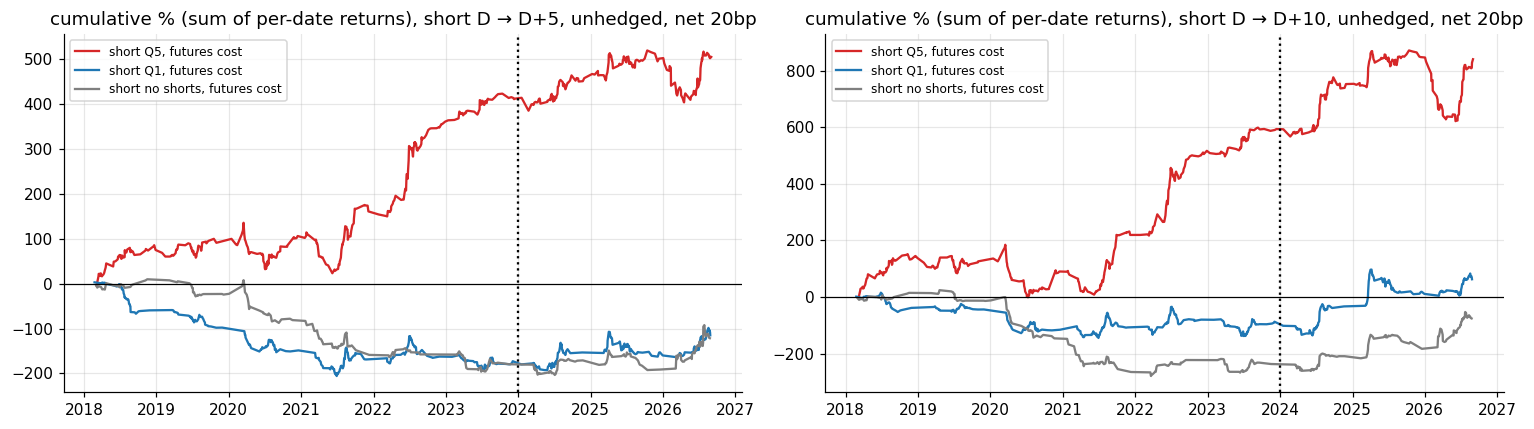

In [20]:
liq = (ev["size"] >= MIN_VAL20).values
Ecl = np.minimum(ev.E.values, D + 5)                 # last ban day, capped (a few long bans are not standard)
def book(g_, x, pm, entry="D"):
    m = (grp == g_) & liq & pm & ok_ev
    st_ = D[m] if entry == "D" else Ecl[m]
    en_ = D[m] + x
    keep = en_ > st_
    r = -(C_RAW[en_[keep] + 1, J[m][keep]] - C_RAW[st_[keep] + 1, J[m][keep]])
    return pd.Series(r).groupby(ev.Ddate.values[m][keep]).mean()

def line(r, cost):
    r = r.dropna() - cost / 1e4
    return dict(dates=len(r), net_bp=r.mean() * 1e4, t=r.mean() / r.std() * np.sqrt(len(r)), hit=(r > 0).mean())

rows = []
for x in [1, 2, 3, 5, 8, 10, 15]:
    for per, pm in [("2018-23", ~ev.oos.values), ("2024-26", ev.oos.values)]:
        q5f, q1f, nsf = book("Q5", x, pm), book("Q1", x, pm), book("no shorts", x, pm)
        items = [("Q5 short futures (from D)", q5f, COST_FUT_BPS), ("Q1 short futures (control)", q1f, COST_FUT_BPS),
                 ("no-shorts short futures (control)", nsf, COST_FUT_BPS), ("Q5 short - Q1 short, gross (unwind part)", q5f - q1f, 0)]
        if x >= 5:
            items.insert(1, ("Q5 short stock (from ban end)", book("Q5", x, pm, entry="E"), COST_SHORT_STOCK_BPS))
        for lab_, r, cost in items:
            rows.append(dict(version=lab_, x=x, period=per, **line(r, cost)))
tt = pd.DataFrame(rows)
order = ["Q5 short futures (from D)", "Q5 short stock (from ban end)", "Q1 short futures (control)",
         "no-shorts short futures (control)", "Q5 short - Q1 short, gross (unwind part)"]
print(tt.pivot_table(index=["version", "x"], columns="period", values=["net_bp", "t", "hit"]).round(2).reindex(order, level=0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, x in zip(ax, [5, 10]):
    for g_, c in [("Q5", "C3"), ("Q1", "C0"), ("no shorts", "C7")]:
        r = pd.concat([book(g_, x, ~ev.oos.values), book(g_, x, ev.oos.values)]).sort_index() - COST_FUT_BPS / 1e4
        a.plot(r.index, r.cumsum() * 100, color=c, label=f"short {g_}, futures cost")
    a.axhline(0, color="k", lw=.8); a.axvline(IS_END, color="k", ls=":")
    a.set_title(f"cumulative % (sum of per-date returns), short D → D+{x}, unhedged, net 20bp"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
- **Short Q5 futures at the close of D, unhedged, net of 20bp:** 1 day **+43bp (t = 3.2) / +88bp (t = 4.1)**
  (2018–23 / 2024–26); 2 days +62 / +109bp (t ≈ 3.0); 10 days +158 / +127bp; 15 days **+217 / +250bp (t = 3.8 / 2.8)**.
  Profitable in both periods at every horizon, with hit rates of 54–62%.
- **The controls lose.** Shorting Q1 or no-shorts stocks the same way loses money in 2018–23 (−22 to −130bp), so the
  P&L is not the market falling. **Q5 − Q1, gross,** is +61 / +125bp at 1 day and +227 / +290bp at 15 days, with t = 3–4.6.
- **A stock short misses it.** Waiting until margin shorting reopens (the last ban day, ~D+3) loses at 5–8 days
  (−14 to −118bp net) and only breaks even-to-positive at 15 days. The first ~3 days, where much of the fall happens,
  are only reachable with futures (or SBL borrow). **This is a futures trade.**
- Caveats: (i) these are stock returns charged a futures cost; the trade must be re-run on actual single-stock
  futures prices (the data is in `stock_futures.csv`), especially their close on D and their liquidity. (ii) Unhedged
  shorts carry market risk; longer holds give money back when the market rallies (see 4d raw).

## 7. Conclusion

| question | answer |
|---|---|
| Does short interest come back? | Yes. Q5 balances sit at ~0% through the ban (D to D+3), then rebuild: 28% of the pre-ban level on D+4, 80% by D+15. |
| Do heavily shorted stocks fall after D? | **Yes.** Q5 vs market: −56bp on D+1 (t = −9.3), −113bp by D+5, −251bp by D+15. Monotone across quintiles; no-shorts flat. |
| Bigger than an ordinary stretch? | Beyond all 2,000 same-stock random windows at every x from 1 to 15 (z = −8 to −13); Q5 − Q1 likewise. |
| t-stat bootstrap (1,000 cohort windows) | Q5 t = −4.7 to −7.4 and Q5 − Q1 t = −4.5 to −5.8 across 3–15 days, all beyond every random window. |
| When? | Outside the null band from D+1 (t = −6.9). Biggest single day is D+1; a second leg follows as shorts return. Keeps drifting down to ~D+35 (−327bp), then flattens. |
| Is it these dates? | The window starting on D is the most negative of 81 shifted windows. |
| Artifacts? | Not ex-dividend (unchanged with ex-dates removed); median larger than mean; 64% of events fall. |
| Stable? | Negative all 9 years, significant in 7; 2018–23 and 2024–26 both t ≤ −3.5. 2026 is the weakest (partial year). Strongest in large caps. |
| Tradeable? | **Short single-stock futures at the close of D**: +43 / +88bp net at 1 day, +217 / +250bp at 15 days (t ≈ 3–4), unhedged. A stock short misses the first days and does not work. |

**In one sentence.** The unwind is much bigger and cleaner than the climb. Heavily shorted stocks fall about 1% in the week
after the forced-cover deadline and ~2.5% in three weeks, relative to the market, starting the very first day, in
every year and in large caps. The trade that captures it is a single-stock-futures short entered at the deadline
close.

**Caveats.** P&L uses stock returns with a futures cost, so re-run on actual TAIFEX single-stock futures (the data is
already pulled). The drift beyond ~D+20 overlaps the stock's next deadline and the general short-interest anomaly.
2026 is weak so far. Unhedged shorts carry market risk.